In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('banking_data.csv')

# Basic info
print(df.shape)
print(df.columns)

(45216, 19)
Index(['age', 'job', 'marital', 'marital_status', 'education', 'default',
       'balance', 'housing', 'loan', 'contact', 'day', 'month', 'day_month',
       'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')


In [3]:
# Check for redundancy
marital_count = df['marital'].value_counts()
marital_status_count = df['marital_status'].value_counts()
print(marital_count)
print(marital_status_count)

# Remove redundant column
df.drop(columns=['marital_status'], inplace=True)
print(df.columns)

marital
married     27216
single      12790
divorced     5207
Name: count, dtype: int64
marital_status
married     27216
single      12790
divorced     5207
Name: count, dtype: int64
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'day_month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')


In [6]:
# Check missing values
print(df.count())

# Check if missing values are from same rows
missing_values_marital = df[df['marital'].isnull()].index
missing_values_education = df[df['education'].isnull()].index
print(missing_values_marital)
print(missing_values_education)

# Drop missing rows
df.dropna(subset=['education'], inplace=True)
df.dropna(subset=['marital'], inplace=True)
print(df.shape)

age          45216
job          45216
marital      45213
education    45213
default      45216
balance      45216
housing      45216
loan         45216
contact      45216
day          45216
month        45216
day_month    45216
duration     45216
campaign     45216
pdays        45216
previous     45216
poutcome     45216
y            45216
dtype: int64
Index([44996, 45077, 45209], dtype='int64')
Index([44957, 45137, 45170], dtype='int64')
(45210, 18)


count    45210.000000
mean        40.938465
std         10.619311
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64


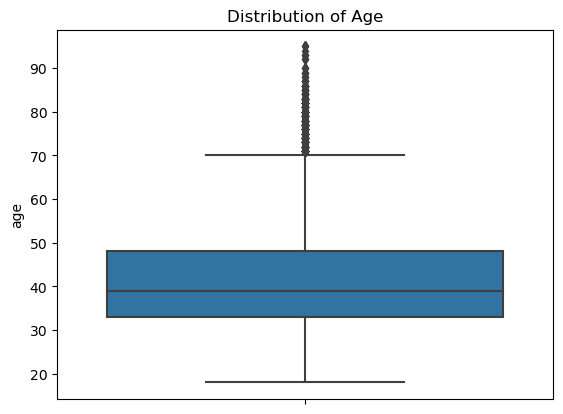

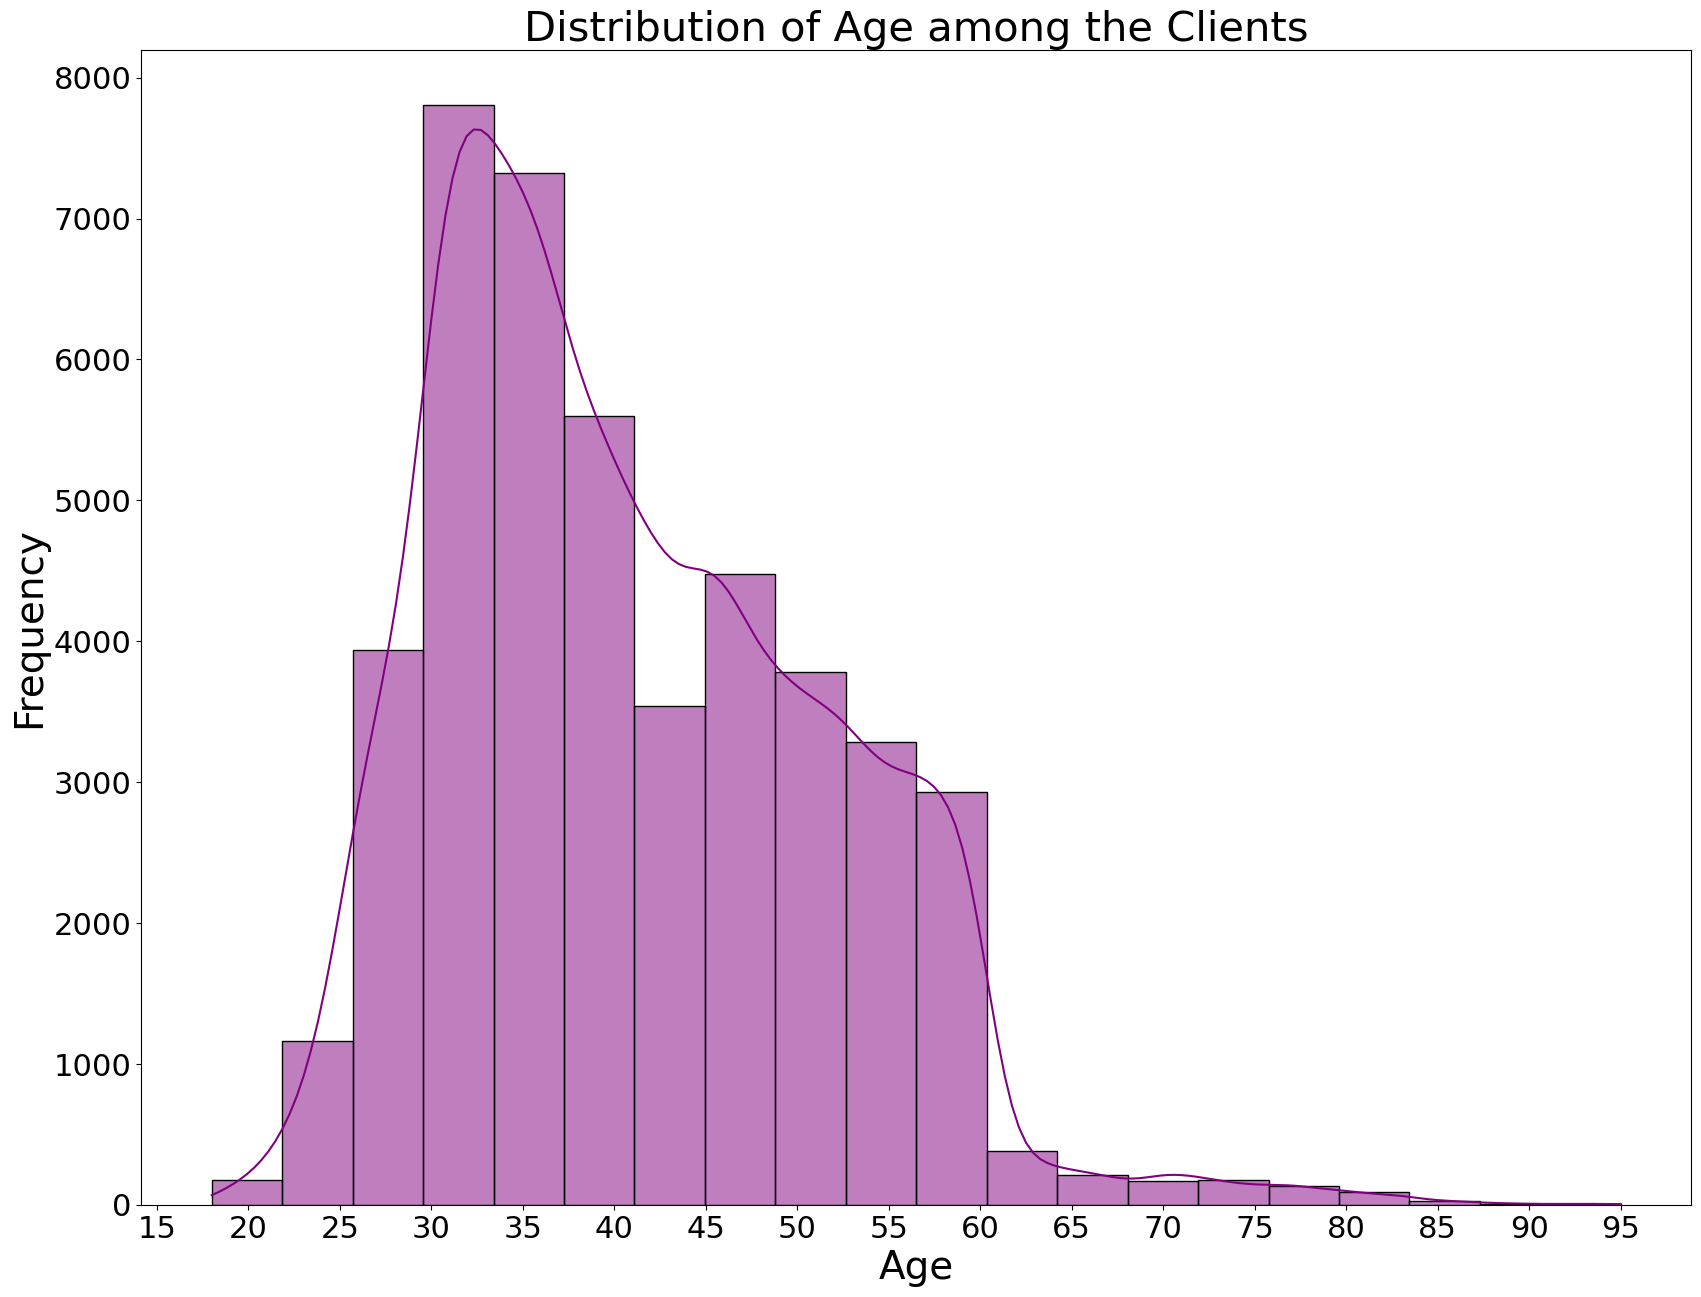

In [8]:
print(df['age'].describe())

sns.boxplot(y='age', data=df)
plt.title('Distribution of Age')
plt.show()

plt.figure(figsize=(20, 15))
sns.histplot(df['age'], kde=True, bins=20, color='purple')
plt.ylabel('Frequency', fontsize=28)
plt.xlabel('Age', fontsize=28)
plt.title('Distribution of Age among the Clients', fontsize=30)
plt.yticks(fontsize=22)
plt.xticks(fontsize=22, ticks=range(15, 100, 5))
plt.show()

job
blue-collar      9731
management       9458
technician       7597
admin.           5171
services         4154
retired          2266
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           936
unknown           288
Name: count, dtype: int64
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']


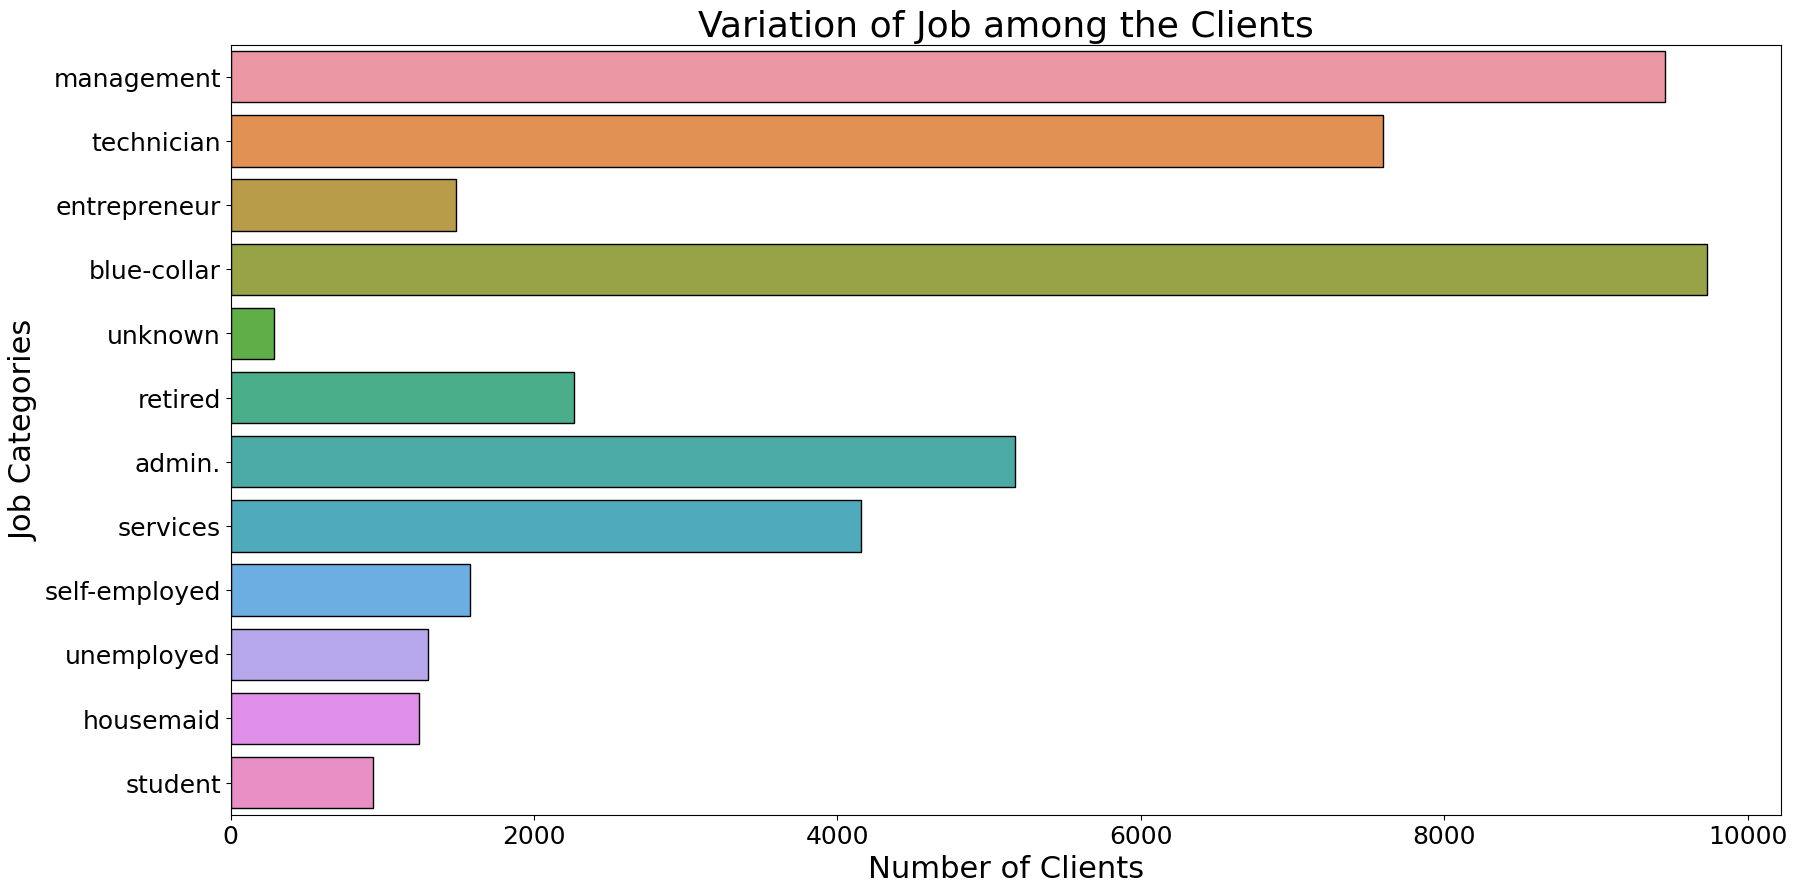

In [14]:
job_count = df['job'].value_counts()
job_categories = df['job'].unique()
print(job_count)
print(job_categories)

plt.figure(figsize=(20, 10))
sns.countplot(data=df, y='job', edgecolor='black')
plt.xlabel('Number of Clients', fontsize=22)
plt.ylabel('Job Categories', fontsize=22)
plt.title('Variation of Job among the Clients', fontsize=26)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.show()

marital
married     27216
single      12787
divorced     5207
Name: count, dtype: int64


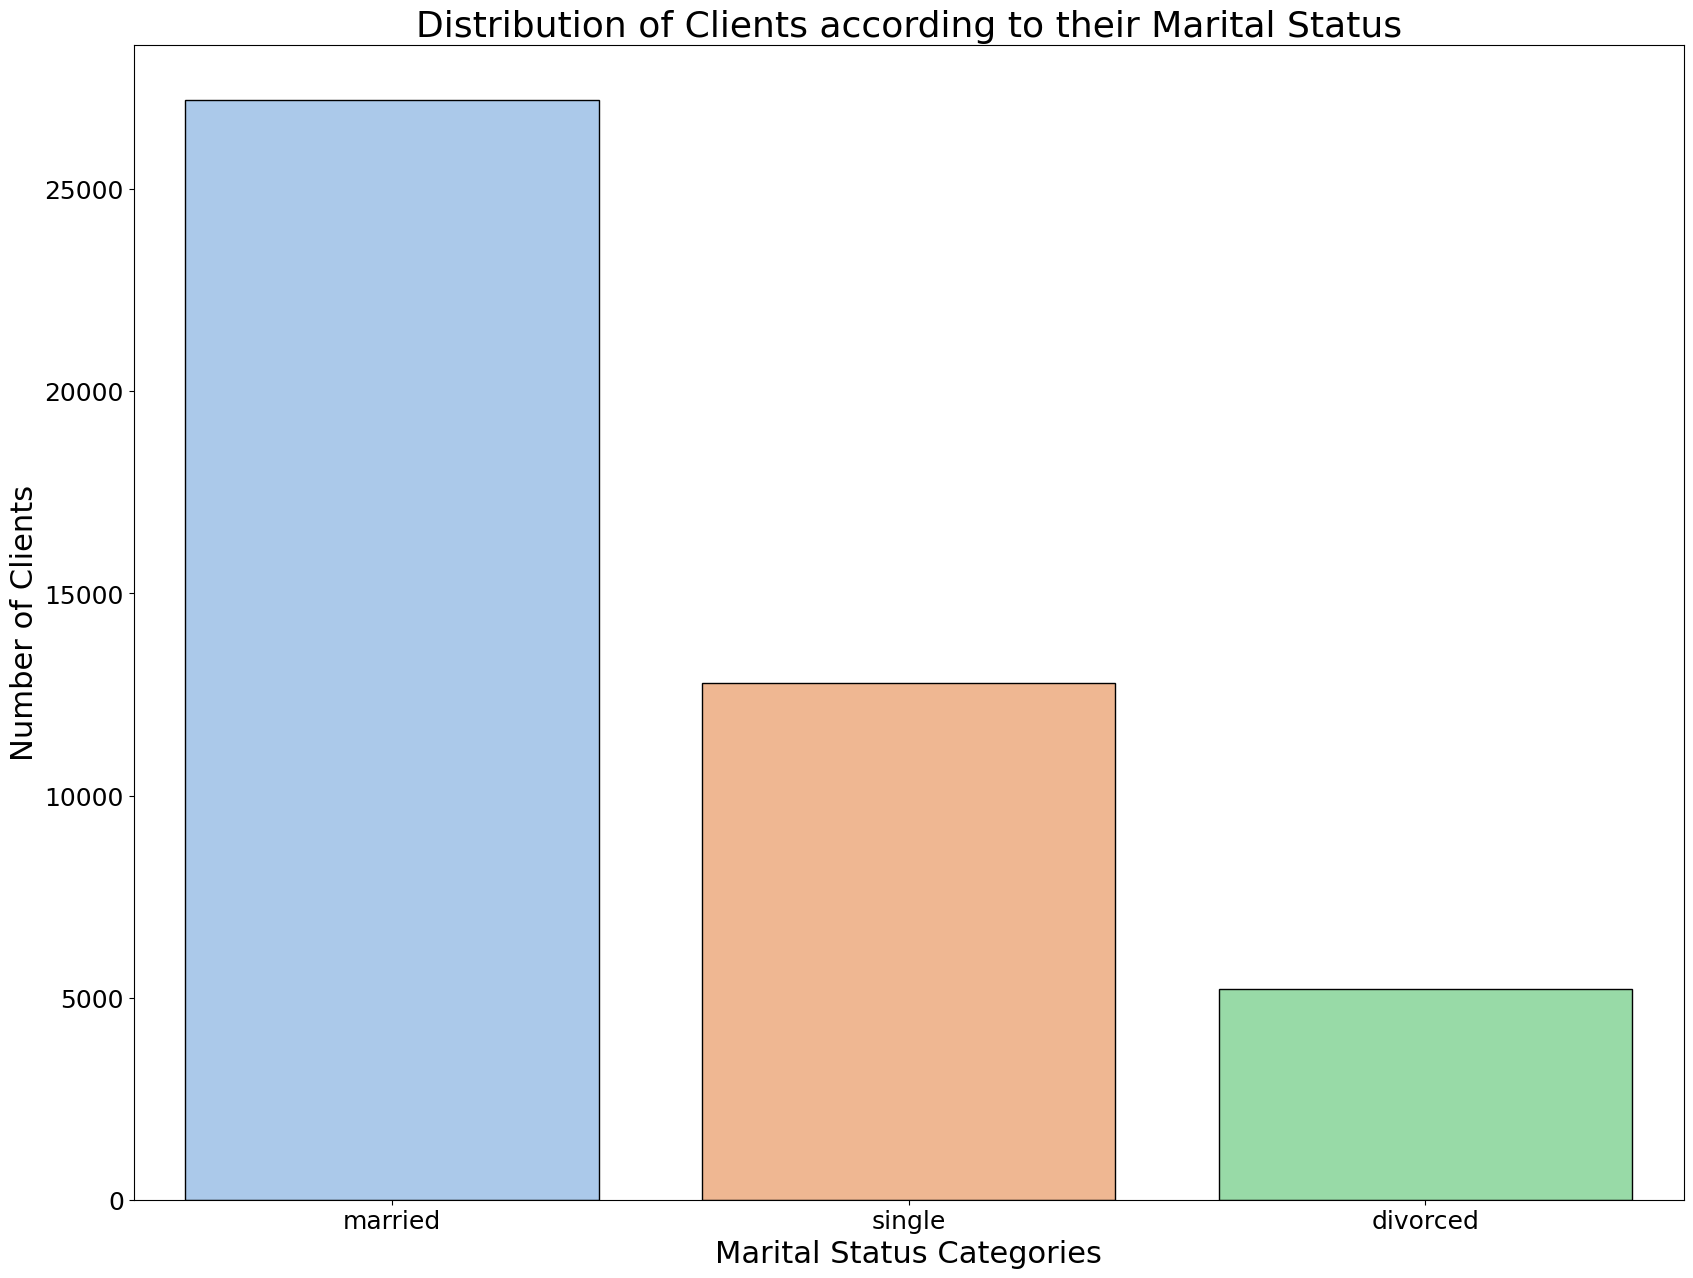

In [16]:
marital_value_count = df['marital'].value_counts()
print(marital_value_count)

plt.figure(figsize=(20, 15))
sns.countplot(data=df, x='marital', palette='pastel', edgecolor='black')
plt.xlabel('Marital Status Categories', fontsize=22)
plt.ylabel('Number of Clients', fontsize=22)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.title('Distribution of Clients according to their Marital Status', fontsize=26)
plt.show()

education
secondary    23201
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64


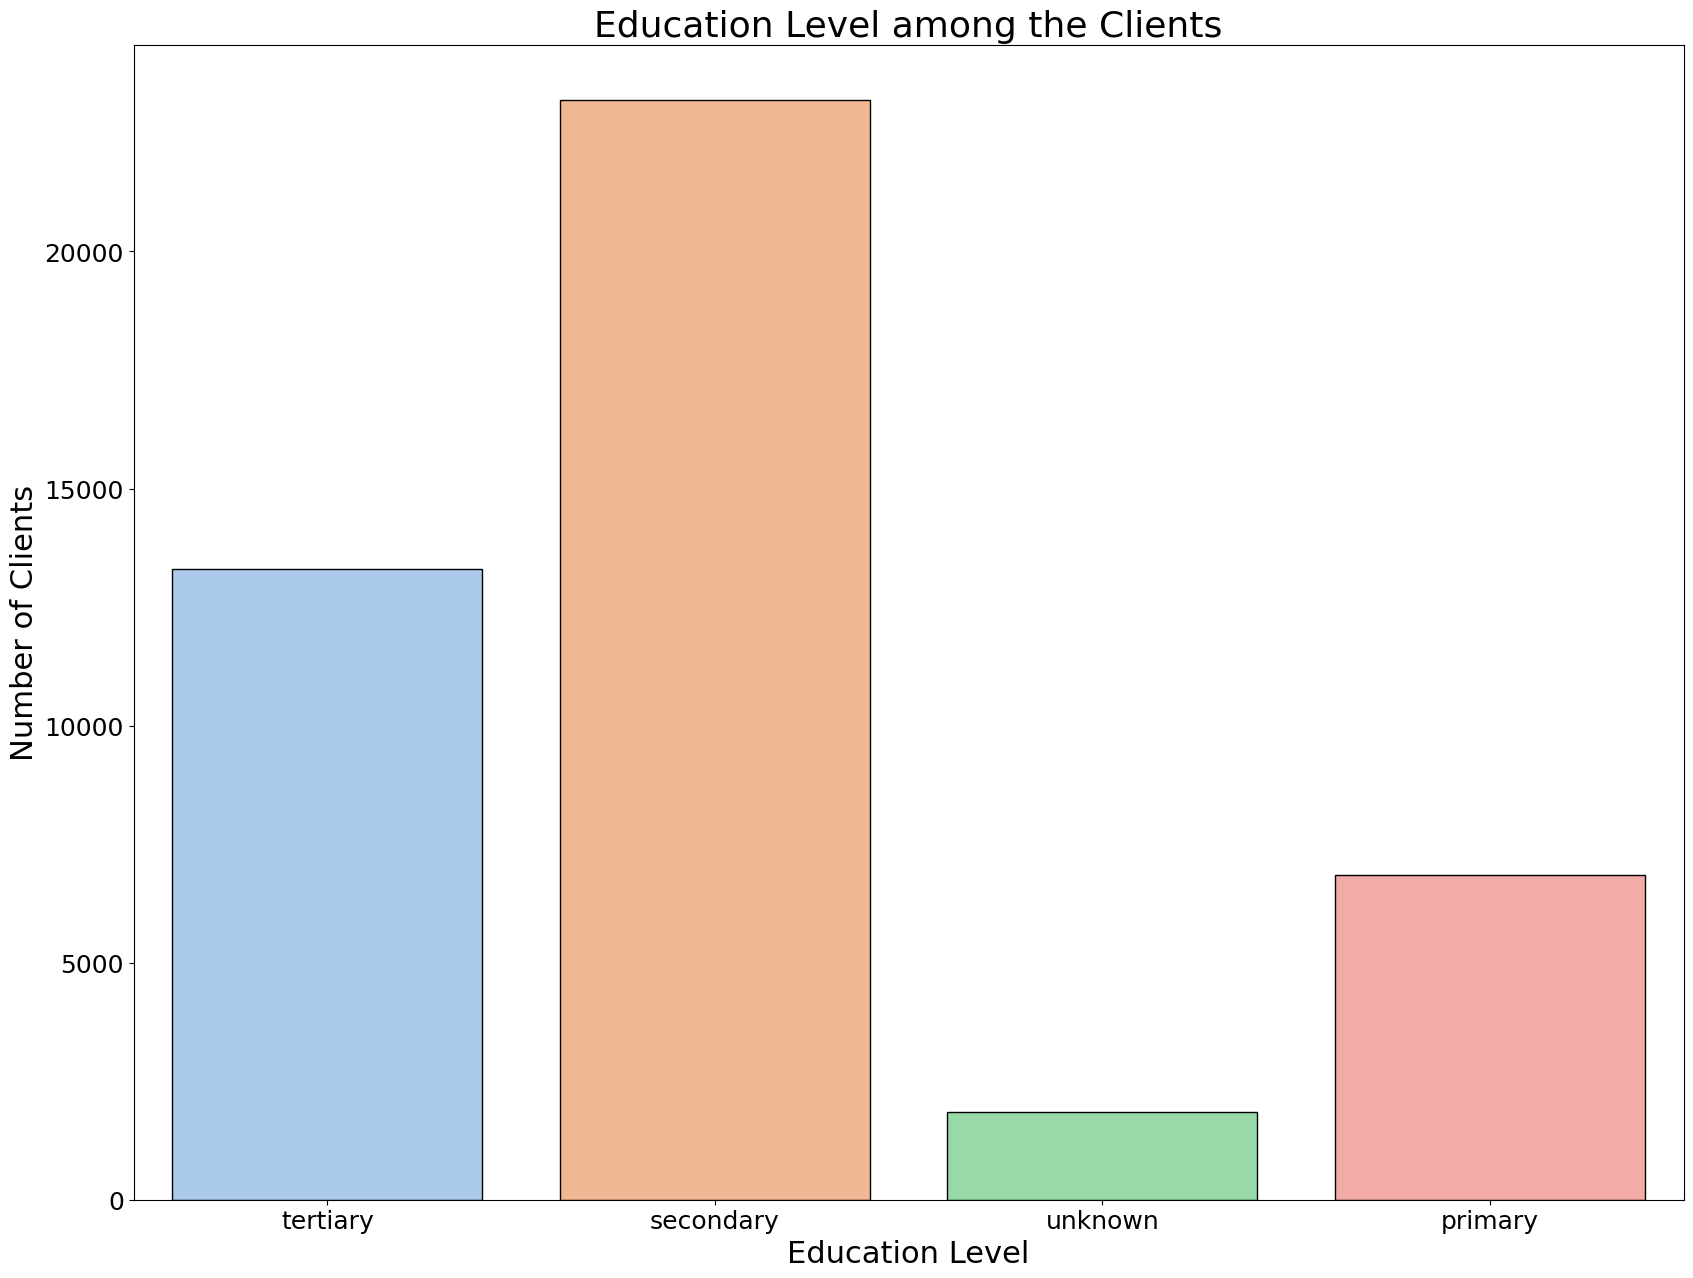

In [18]:
print(df['education'].value_counts())

plt.figure(figsize=(20, 15))
sns.countplot(data=df, x='education', palette='pastel', edgecolor='black')
plt.xlabel('Education Level', fontsize=22)
plt.ylabel('Number of Clients', fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('Education Level among the Clients', fontsize=26)
plt.show()

education
secondary    23201
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64


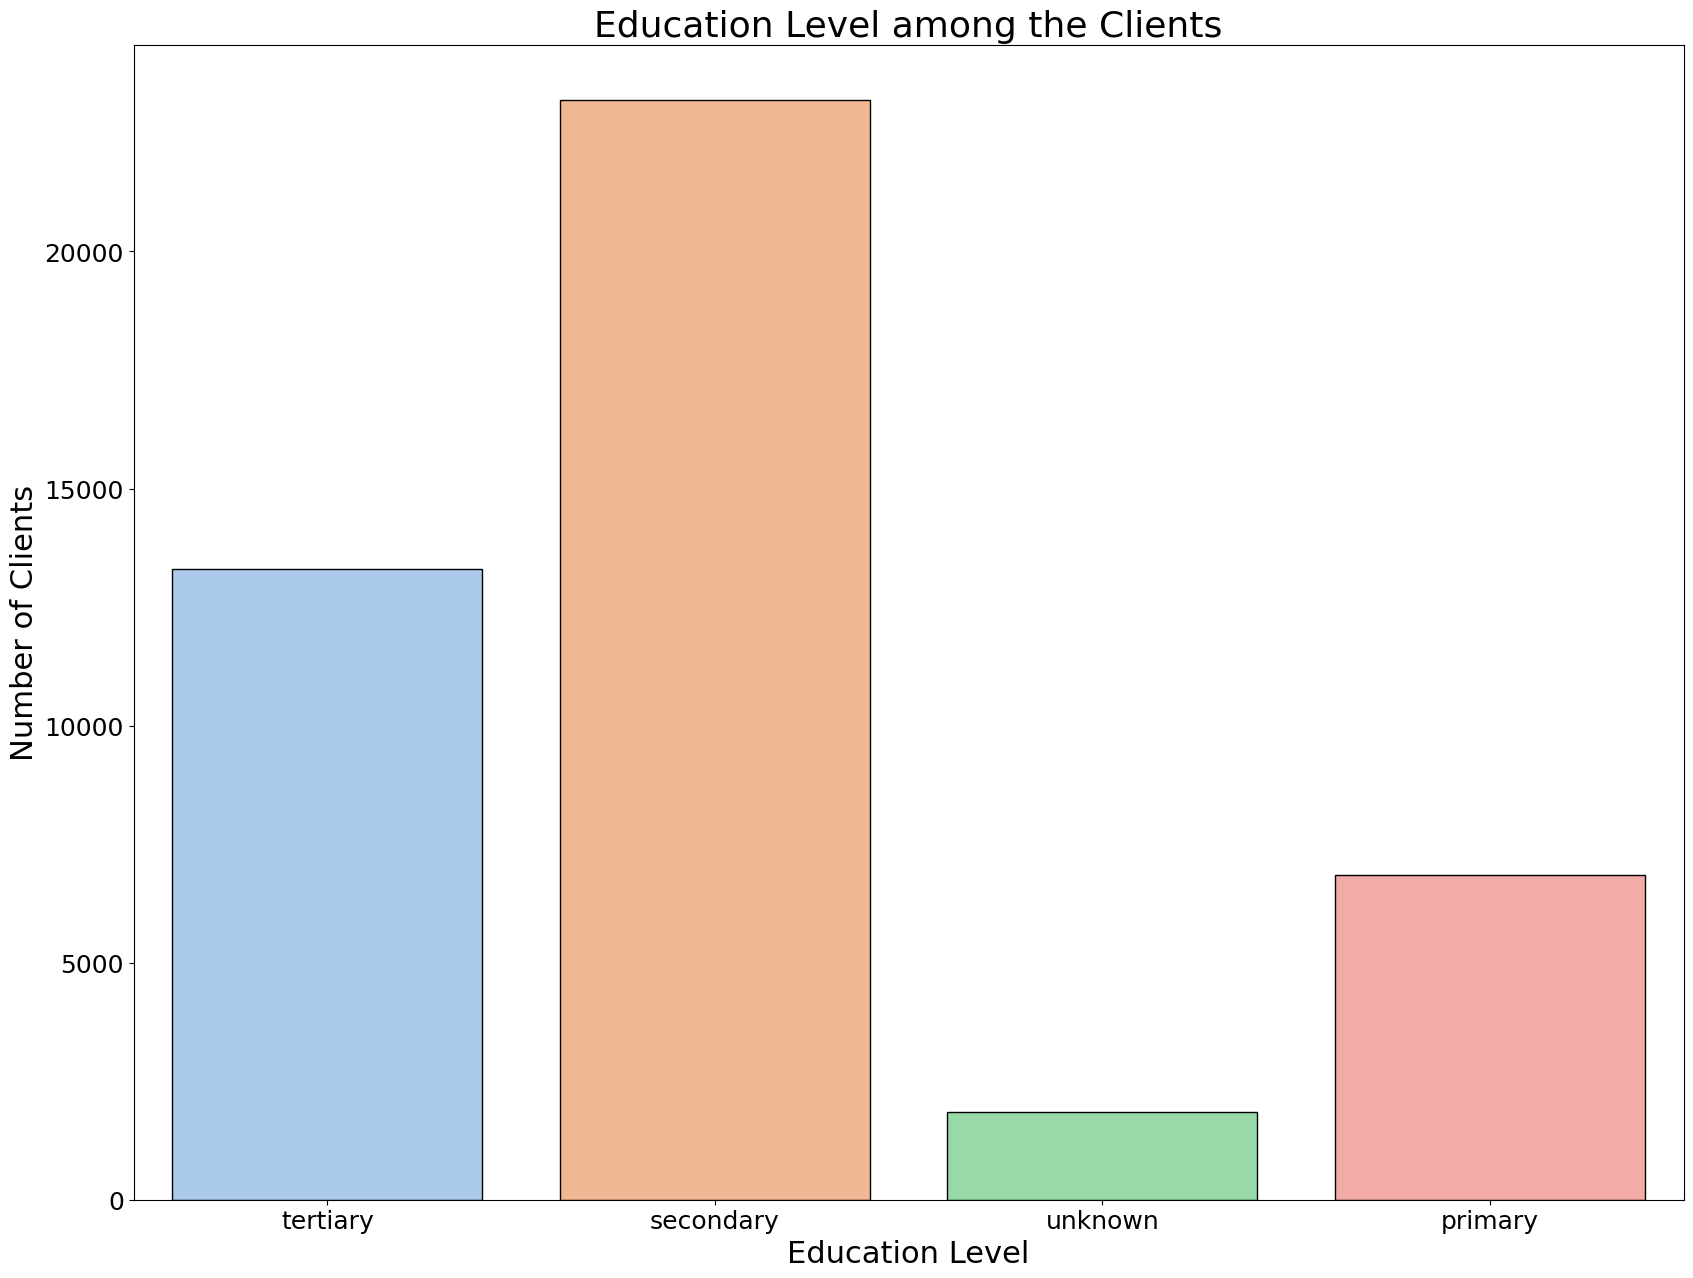

In [20]:
print(df['education'].value_counts())

plt.figure(figsize=(20, 15))
sns.countplot(data=df, x='education', palette='pastel', edgecolor='black')
plt.xlabel('Education Level', fontsize=22)
plt.ylabel('Number of Clients', fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('Education Level among the Clients', fontsize=26)
plt.show()

default
no     44395
yes      815
Name: count, dtype: int64


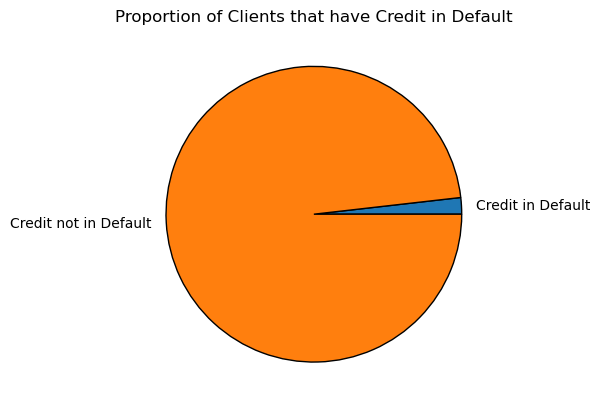

In [22]:
print(df['default'].value_counts())

default_count_yes = (df['default'] == 'yes').sum()
default_count_no = (df['default'] == 'no').sum()

default_count = [default_count_yes, default_count_no]
labels = ['Credit in Default', 'Credit not in Default']

plt.pie(default_count, labels=labels, wedgeprops={'edgecolor': 'black'})
plt.title('Proportion of Clients that have Credit in Default')
plt.show()

count     45210.000000
mean       1362.333024
std        3044.781647
min       -8019.000000
25%          72.000000
50%         448.500000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64


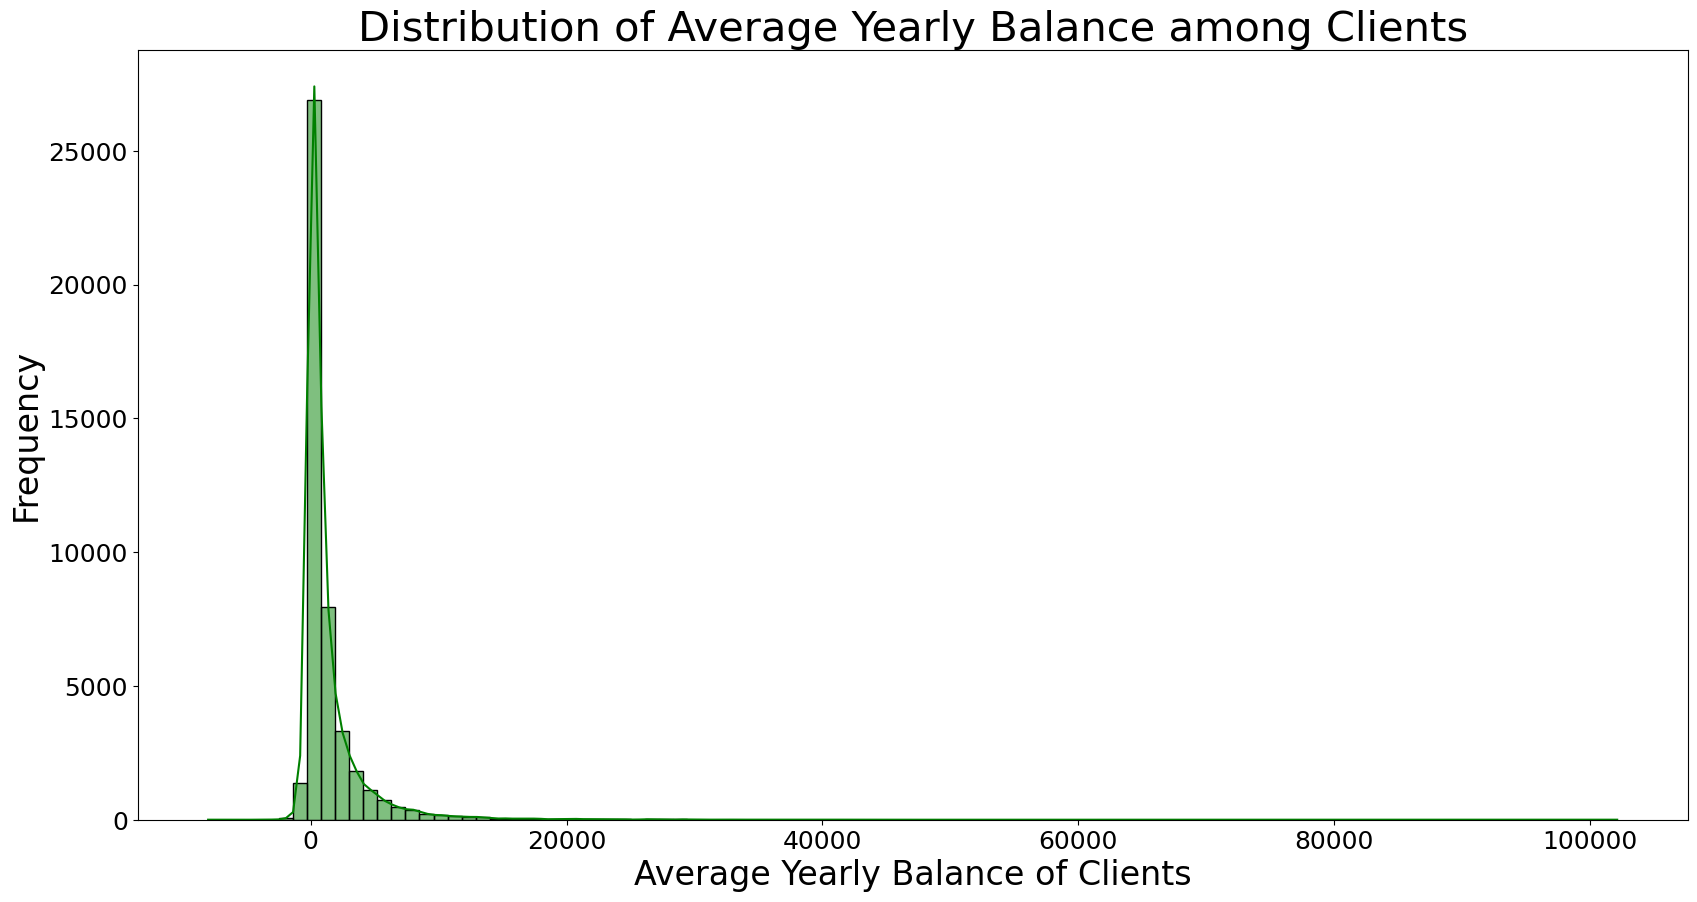

In [24]:
print(df['balance'].describe())

plt.figure(figsize=(20, 10))
sns.histplot(df['balance'], kde=True, bins=100, color='green')
plt.ylabel('Frequency', fontsize=24)
plt.xlabel('Average Yearly Balance of Clients', fontsize=24)
plt.title('Distribution of Average Yearly Balance among Clients', fontsize=30)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.show()

housing
yes    25130
no     20080
Name: count, dtype: int64
The number of clients having housing loan are 25130


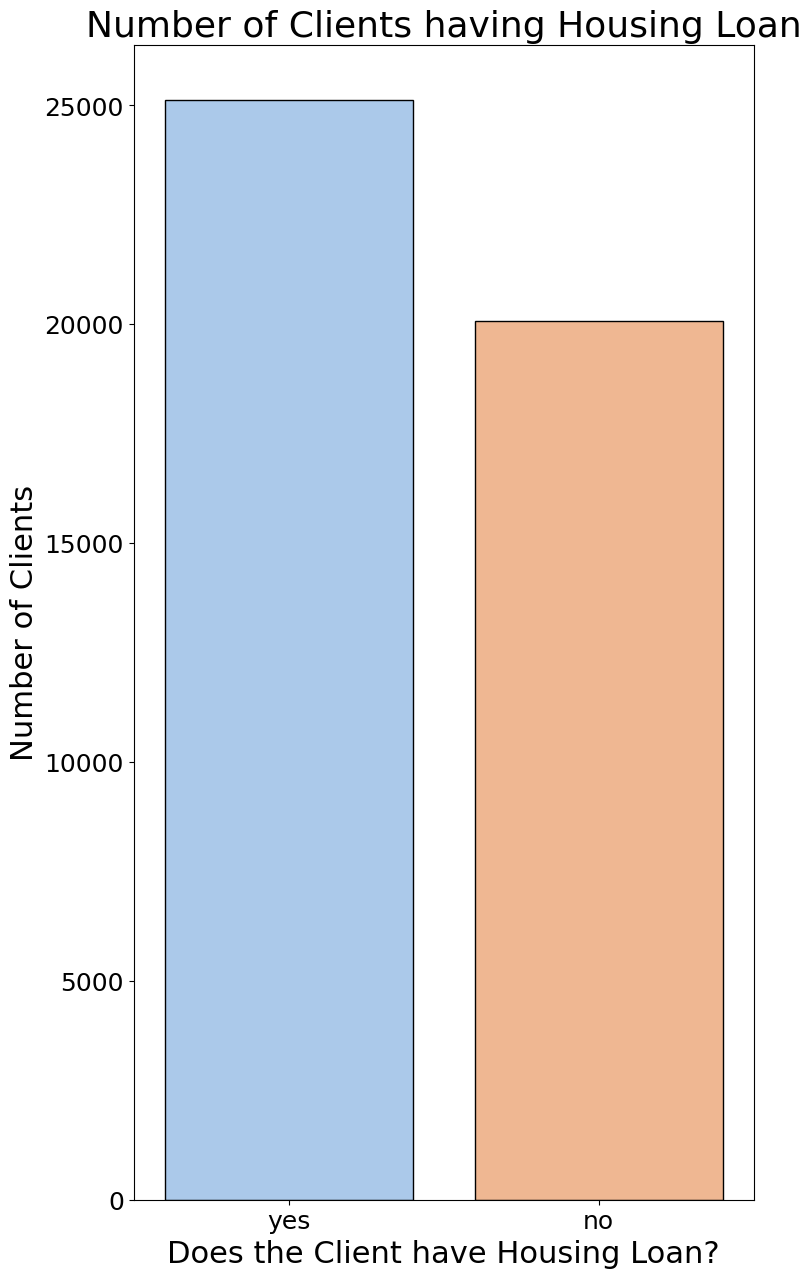

In [26]:
print(df['housing'].value_counts())
housing_loan_clients = (df['housing'] == 'yes').sum()
print(f'The number of clients having housing loan are {housing_loan_clients}')

plt.figure(figsize=(8, 15))
sns.countplot(data=df, x='housing', palette='pastel', edgecolor='black')
plt.xlabel('Does the Client have Housing Loan?', fontsize=22)
plt.ylabel('Number of Clients', fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('Number of Clients having Housing Loan', fontsize=26)
plt.show()

loan
no     37966
yes     7244
Name: count, dtype: int64
The number of clients having personal loan are 7244


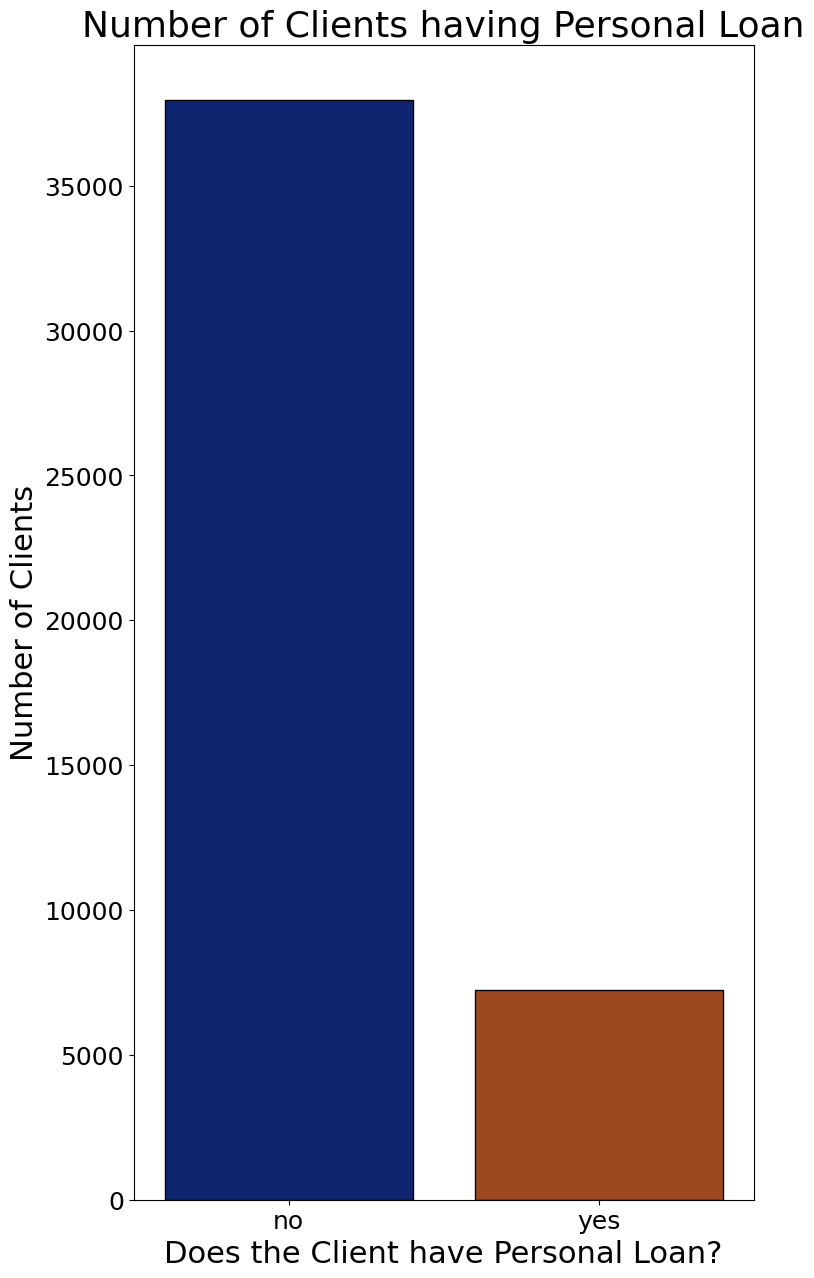

In [28]:
print(df['loan'].value_counts())
personal_loan_clients = (df['loan'] == 'yes').sum()
print(f'The number of clients having personal loan are {personal_loan_clients}')

plt.figure(figsize=(8, 15))
sns.countplot(data=df, x='loan', palette='dark', edgecolor='black')
plt.xlabel('Does the Client have Personal Loan?', fontsize=22)
plt.ylabel('Number of Clients', fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('Number of Clients having Personal Loan', fontsize=26)
plt.show()

contact
cellular     29288
unknown      13020
telephone     2902
Name: count, dtype: int64
Communication types used: ['unknown' 'cellular' 'telephone']


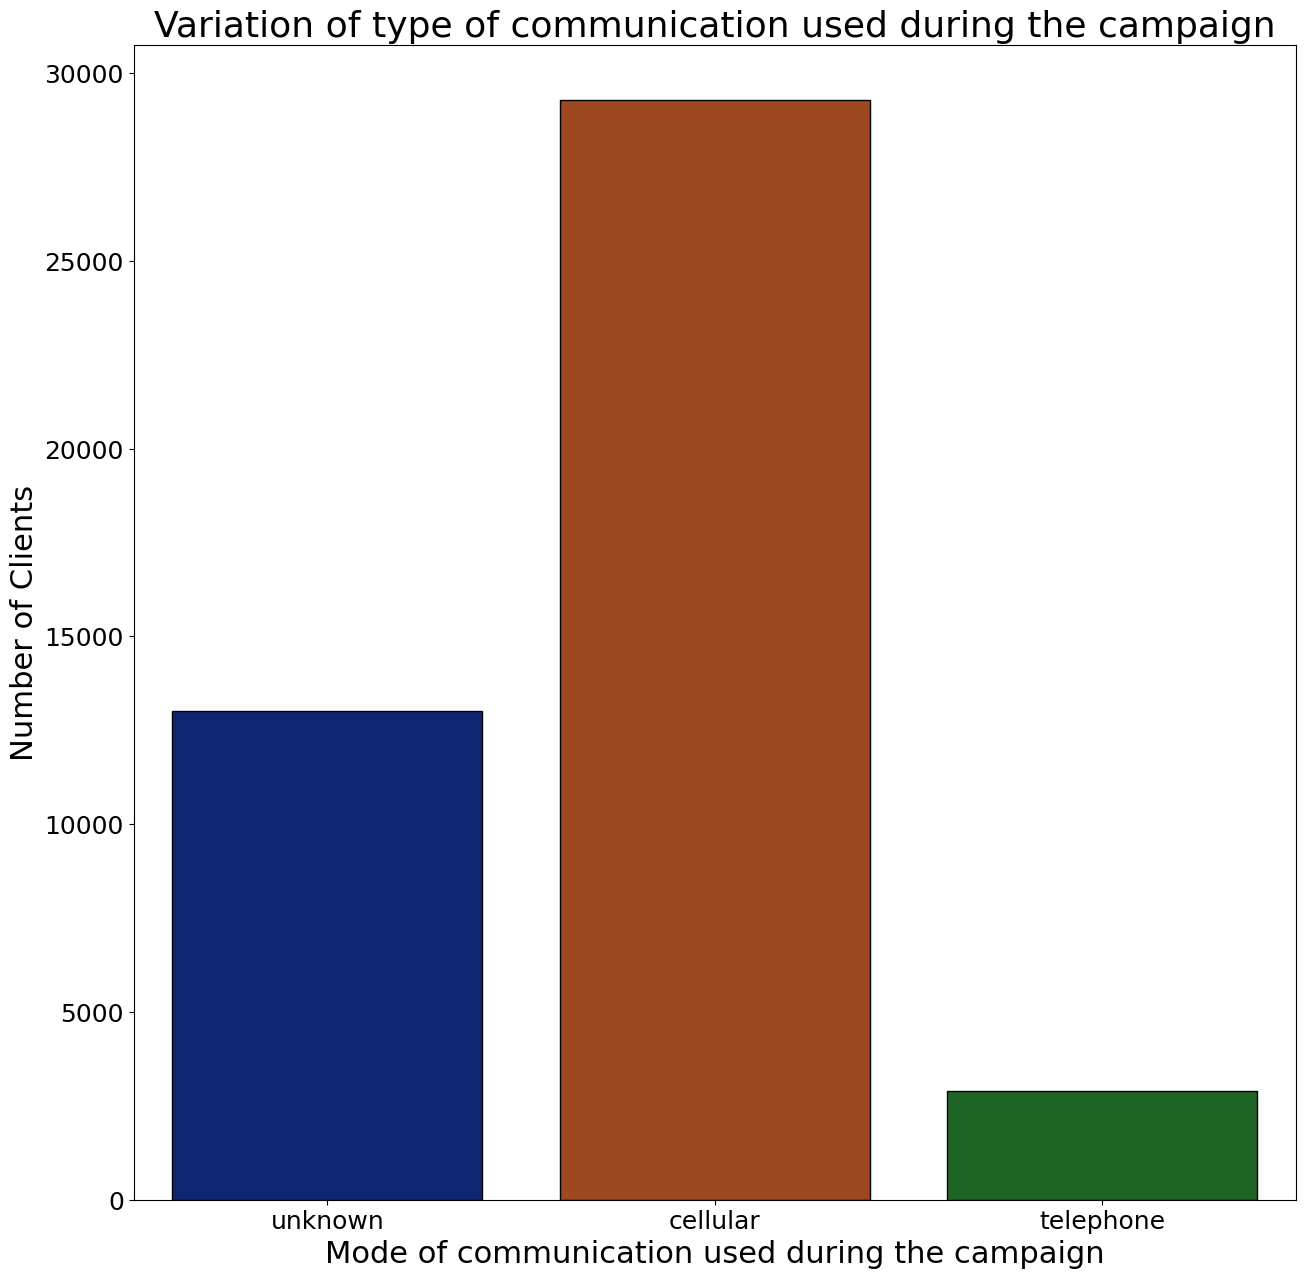

In [30]:
communication_types = df['contact'].unique()
print(df['contact'].value_counts())
print(f'Communication types used: {communication_types}')

plt.figure(figsize=(15, 15))
sns.countplot(data=df, x='contact', palette='dark', edgecolor='black')
plt.xlabel('Mode of communication used during the campaign', fontsize=22)
plt.ylabel('Number of Clients', fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('Variation of type of communication used during the campaign', fontsize=26)
plt.show()

count    45210.000000
mean        15.806923
std          8.322310
min          1.000000
25%          8.000000
50%         16.000000
75%         21.000000
max         31.000000
Name: day, dtype: float64


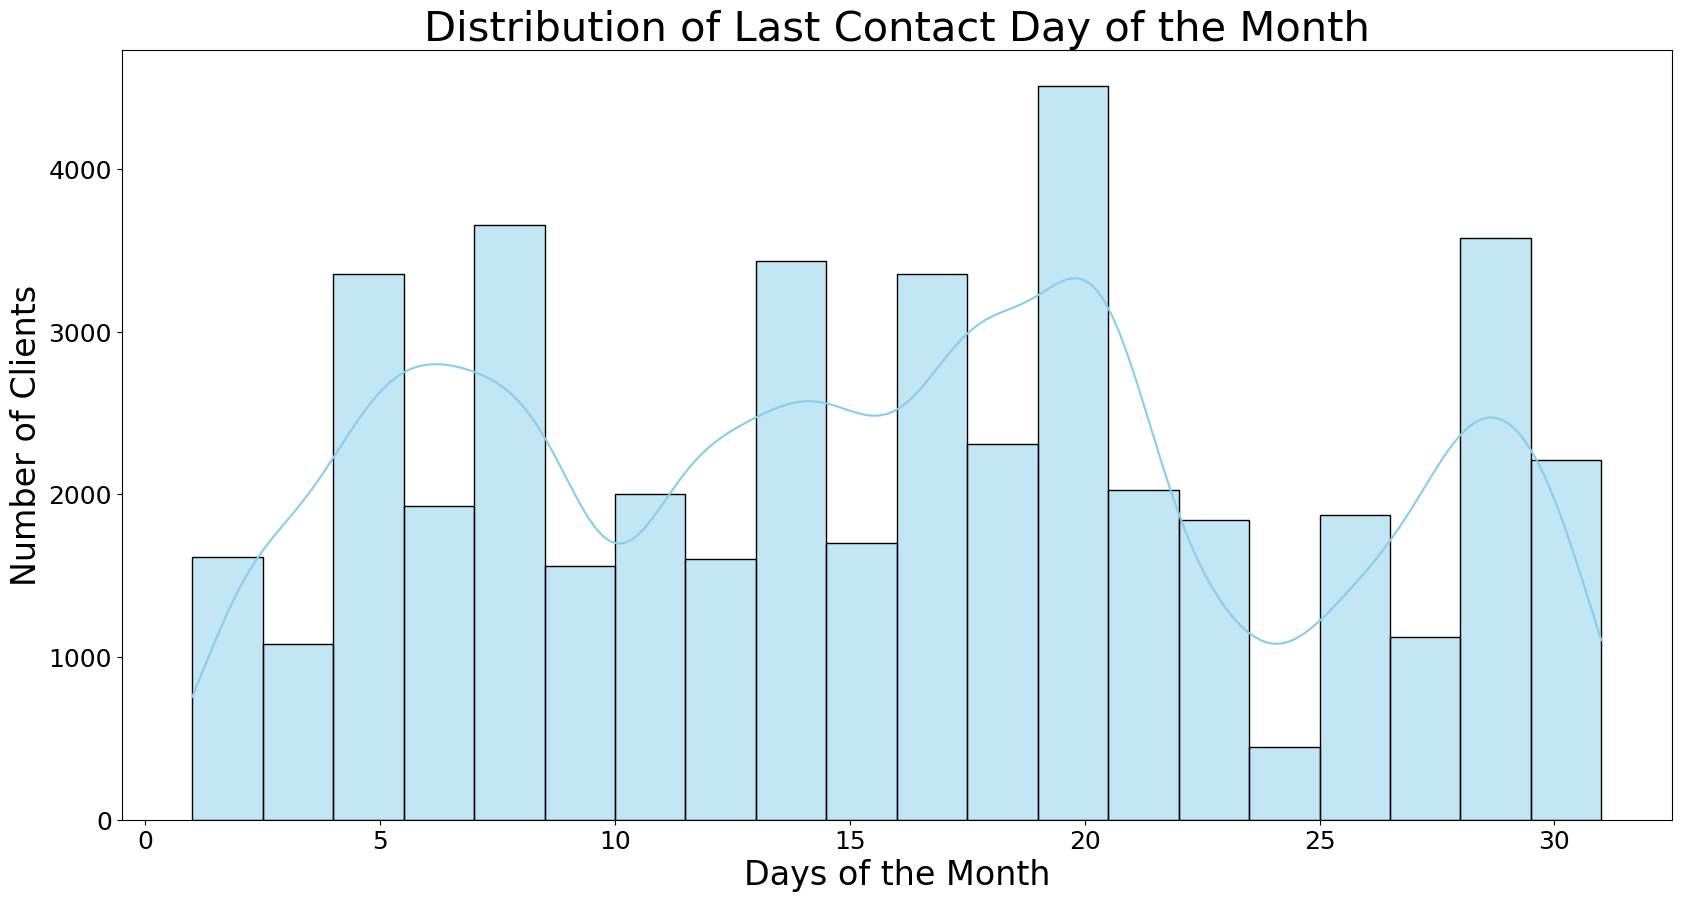

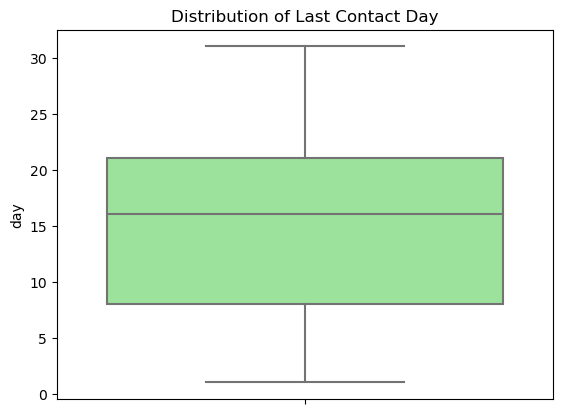

In [32]:
print(df['day'].describe())

plt.figure(figsize=(20, 10))
sns.histplot(data=df, x='day', kde=True, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Days of the Month', fontsize=24)
plt.ylabel('Number of Clients', fontsize=24)
plt.title('Distribution of Last Contact Day of the Month', fontsize=30)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.show()

sns.boxplot(y='day', data=df, color='lightgreen')
plt.title('Distribution of Last Contact Day')
plt.show()

month
may    13766
jul     6895
aug     6247
jun     5341
nov     3972
apr     2932
feb     2649
jan     1403
oct      735
sep      579
mar      477
dec      214
Name: count, dtype: int64


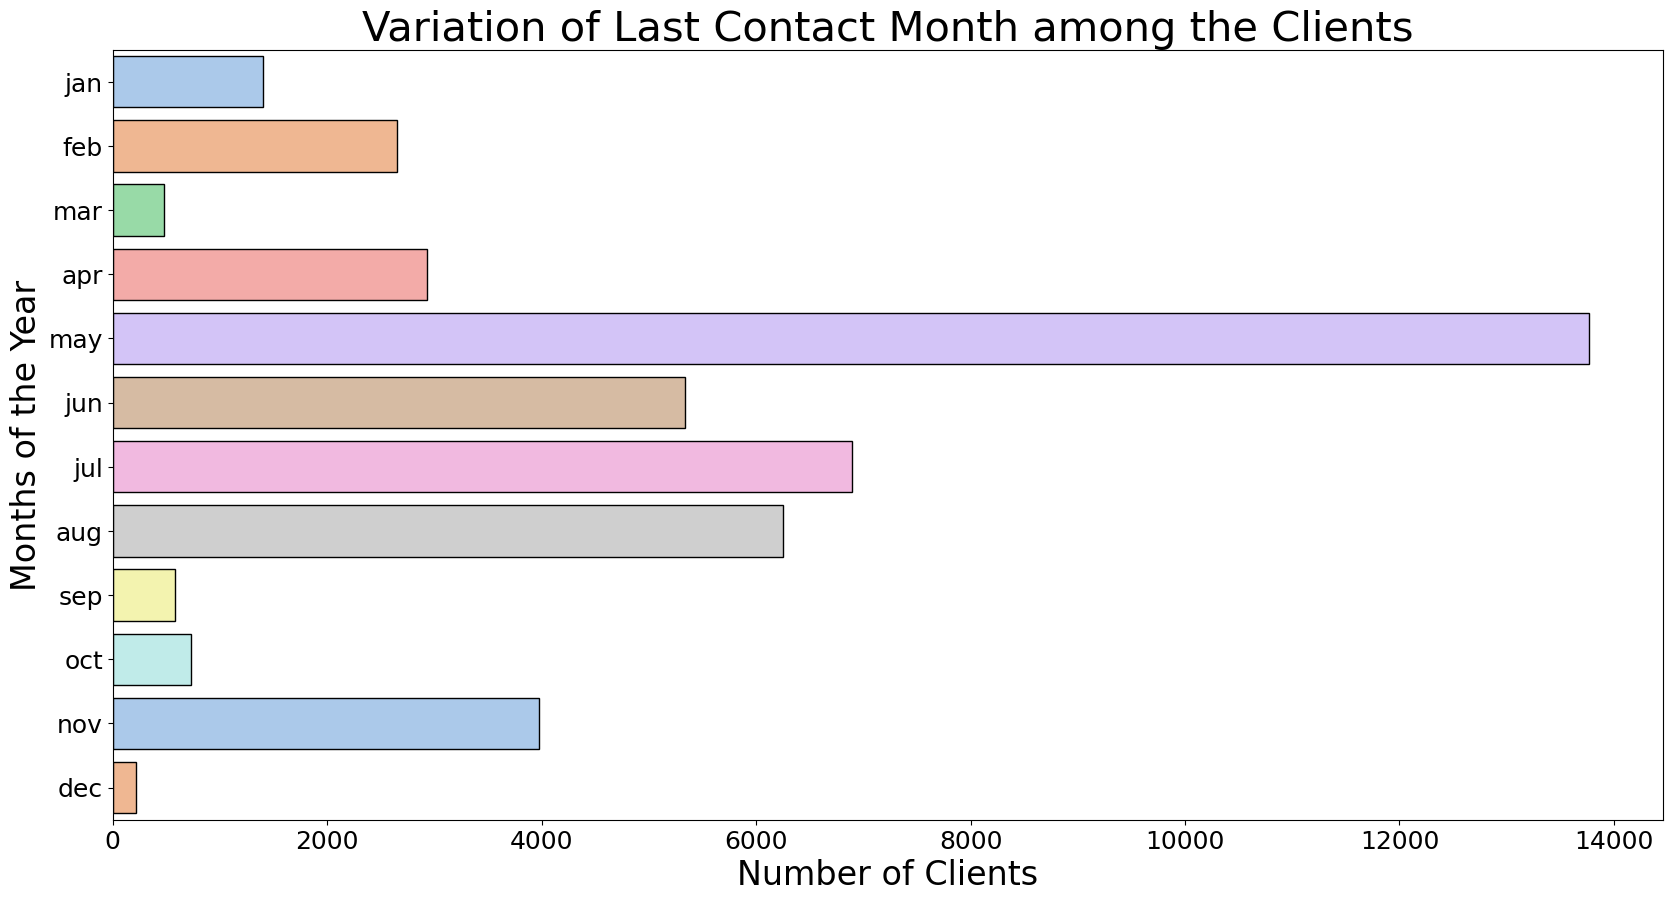

In [34]:
print(df['month'].value_counts())

order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

plt.figure(figsize=(20, 10))
sns.countplot(data=df, y='month', palette='pastel', edgecolor='black', order=order)
plt.ylabel('Months of the Year', fontsize=24)
plt.xlabel('Number of Clients', fontsize=24)
plt.title('Variation of Last Contact Month among the Clients', fontsize=30)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.show()

count    45210.000000
mean       258.155342
std        257.522333
min          0.000000
25%        103.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64


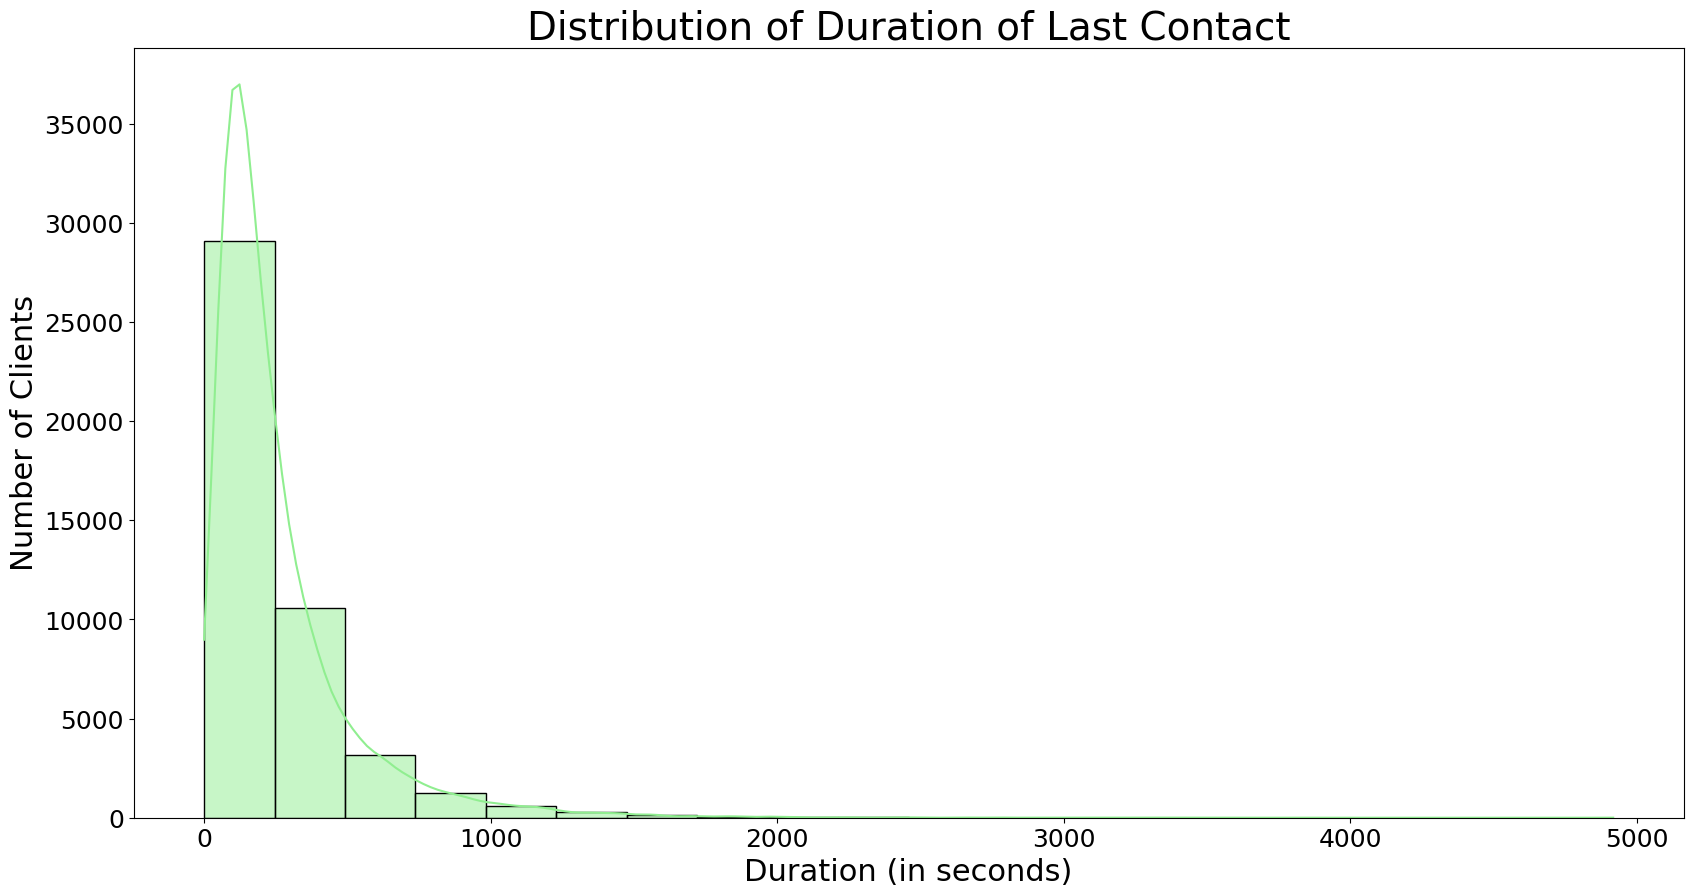

In [36]:
print(df['duration'].describe())

plt.figure(figsize=(20, 10))
sns.histplot(data=df, x='duration', kde=True, bins=20, color='lightgreen')
plt.xlabel('Duration (in seconds)', fontsize=22)
plt.ylabel('Number of Clients', fontsize=22)
plt.title('Distribution of Duration of Last Contact', fontsize=28)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.show()

[ 1  2  3  5  4  6  7  8  9 10 11 12 13 19 14 24 16 32 18 22 15 17 25 21
 43 51 63 41 26 28 55 50 38 23 20 29 31 37 30 46 27 58 33 35 34 36 39 44]
count    45210.000000
mean         2.763791
std          3.098059
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64


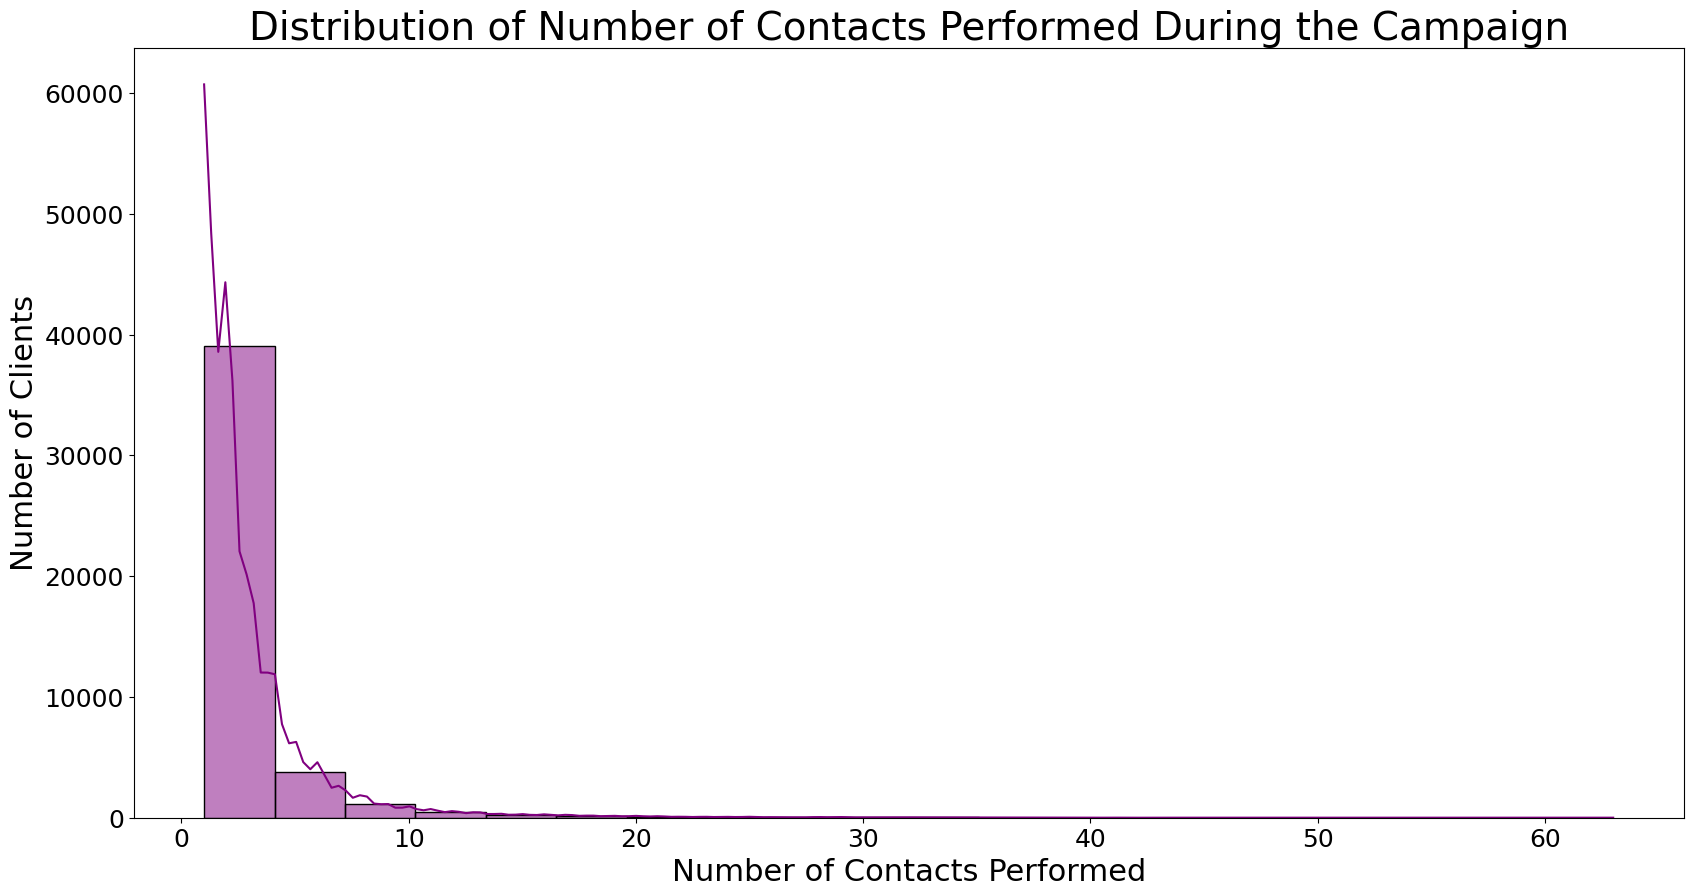

In [38]:
print(df['campaign'].unique())
print(df['campaign'].describe())

plt.figure(figsize=(20, 10))
sns.histplot(data=df, x='campaign', kde=True, bins=20, color='purple')
plt.xlabel('Number of Contacts Performed', fontsize=22)
plt.ylabel('Number of Clients', fontsize=22)
plt.title('Distribution of Number of Contacts Performed During the Campaign', fontsize=28)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.show()

count    45210.000000
mean        40.187879
std        100.112791
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max        871.000000
Name: pdays, dtype: float64
pdays
-1      36954
 182      167
 92       147
 91       126
 183      126
        ...  
 404        1
 32         1
 551        1
 670        1
 530        1
Name: count, Length: 559, dtype: int64


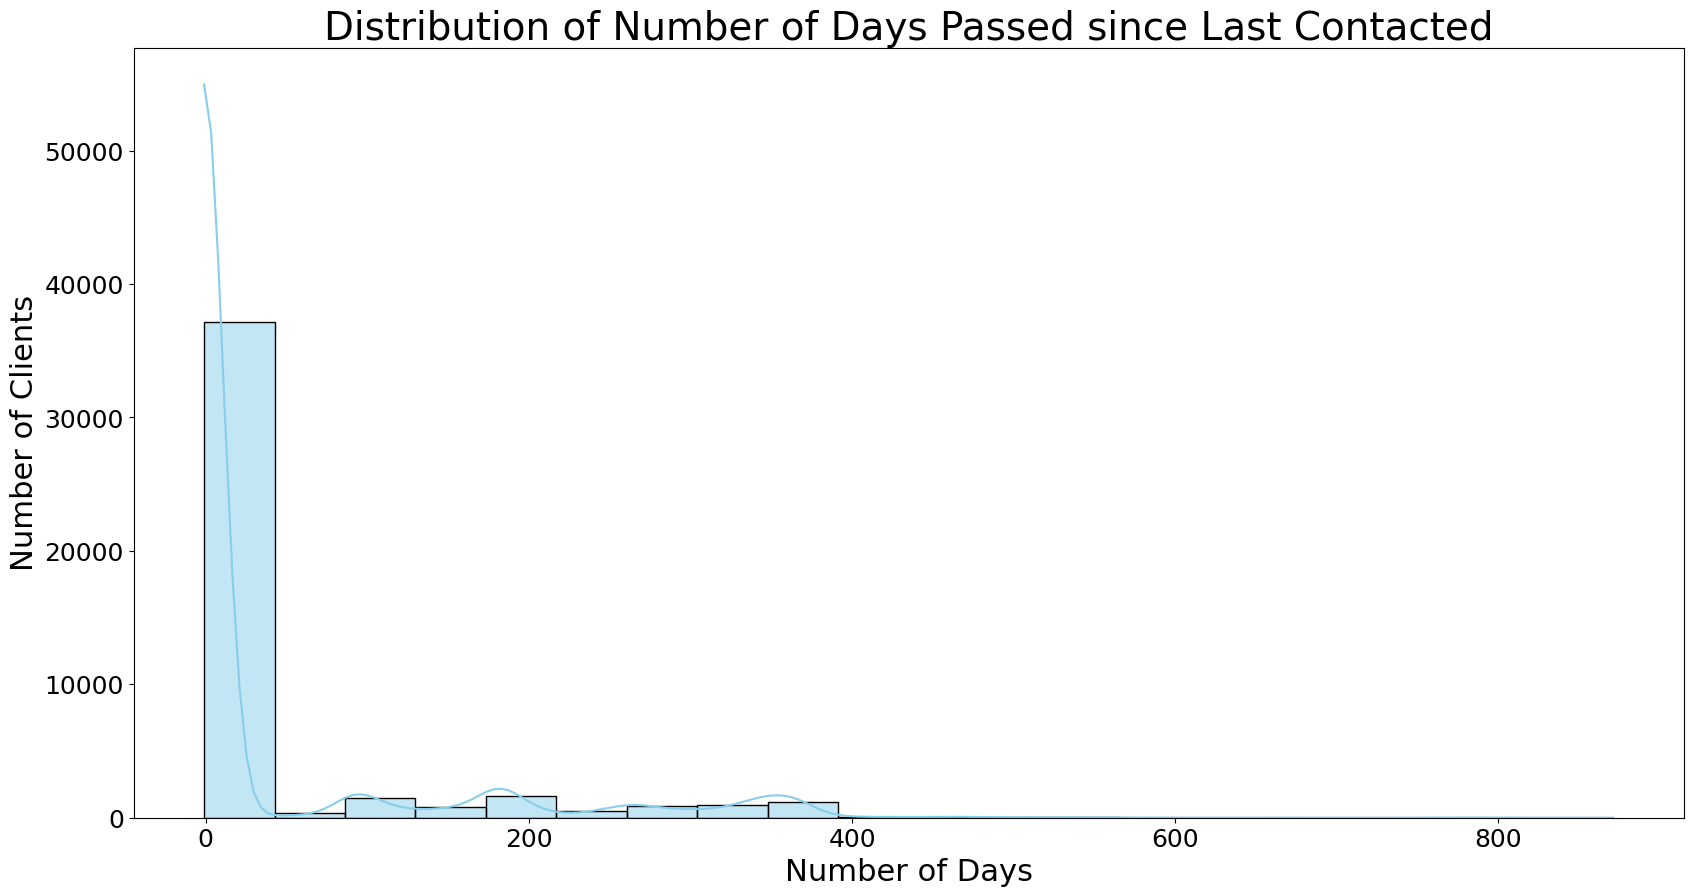

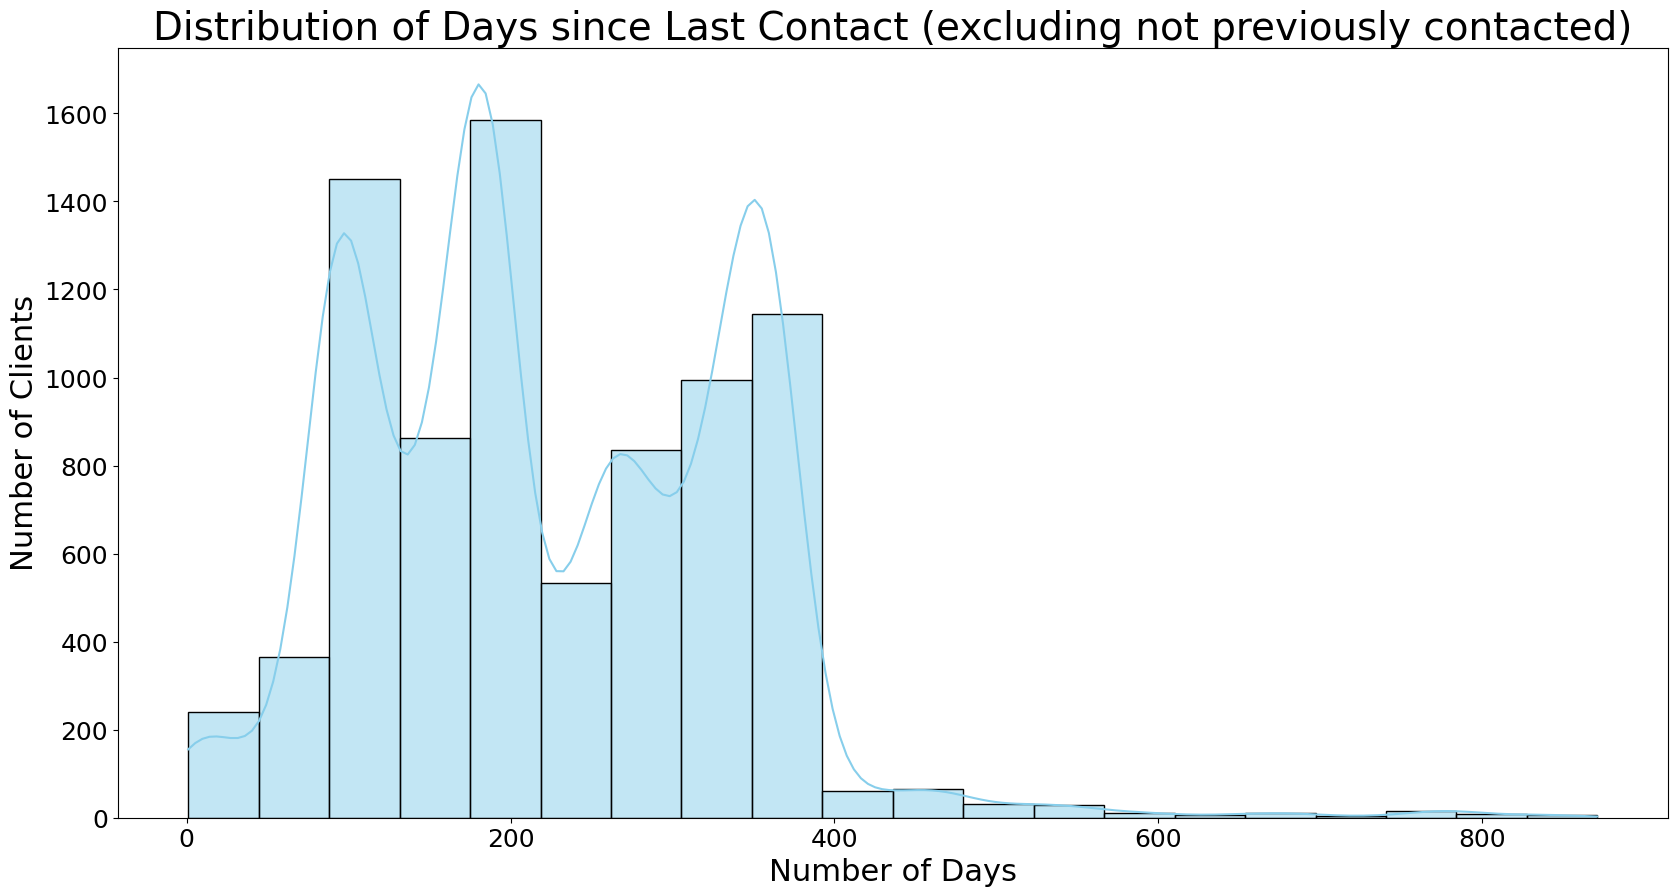

count    8256.000000
mean      224.545543
std       115.339156
min         1.000000
25%       133.000000
50%       194.000000
75%       327.000000
max       871.000000
dtype: float64
Clients previously contacted: 8256
Clients not previously contacted: 36954


In [40]:
print(df['pdays'].describe())
print(df['pdays'].value_counts())

plt.figure(figsize=(20, 10))
sns.histplot(data=df, x='pdays', kde=True, bins=20, color='skyblue')
plt.xlabel('Number of Days', fontsize=22)
plt.ylabel('Number of Clients', fontsize=22)
plt.title('Distribution of Number of Days Passed since Last Contacted', fontsize=28)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.show()

# Exclude clients not previously contacted (-1)
pdays_contacted_previously = df[df['pdays'] != -1]['pdays'].tolist()

plt.figure(figsize=(20, 10))
sns.histplot(x=pdays_contacted_previously, kde=True, bins=20, color='skyblue')
plt.xlabel('Number of Days', fontsize=22)
plt.ylabel('Number of Clients', fontsize=22)
plt.title('Distribution of Days since Last Contact (excluding not previously contacted)', fontsize=28)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.show()

n = pd.Series(pdays_contacted_previously)
print(n.describe())
print(f'Clients previously contacted: {len(pdays_contacted_previously)}')
print(f'Clients not previously contacted: {df["pdays"].count() - len(pdays_contacted_previously)}')

previous
0      36954
1       2772
2       2103
3       1142
4        714
5        459
6        278
7        205
8        130
9         92
10        67
11        65
12        44
13        38
15        20
14        19
17        15
16        13
19        11
20         8
23         8
18         6
22         6
24         5
27         5
21         4
29         4
25         4
30         3
38         2
37         2
26         2
28         2
51         1
275        1
58         1
32         1
40         1
55         1
35         1
41         1
Name: count, dtype: int64
count    45210.000000
mean         0.580513
std          2.303843
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: previous, dtype: float64


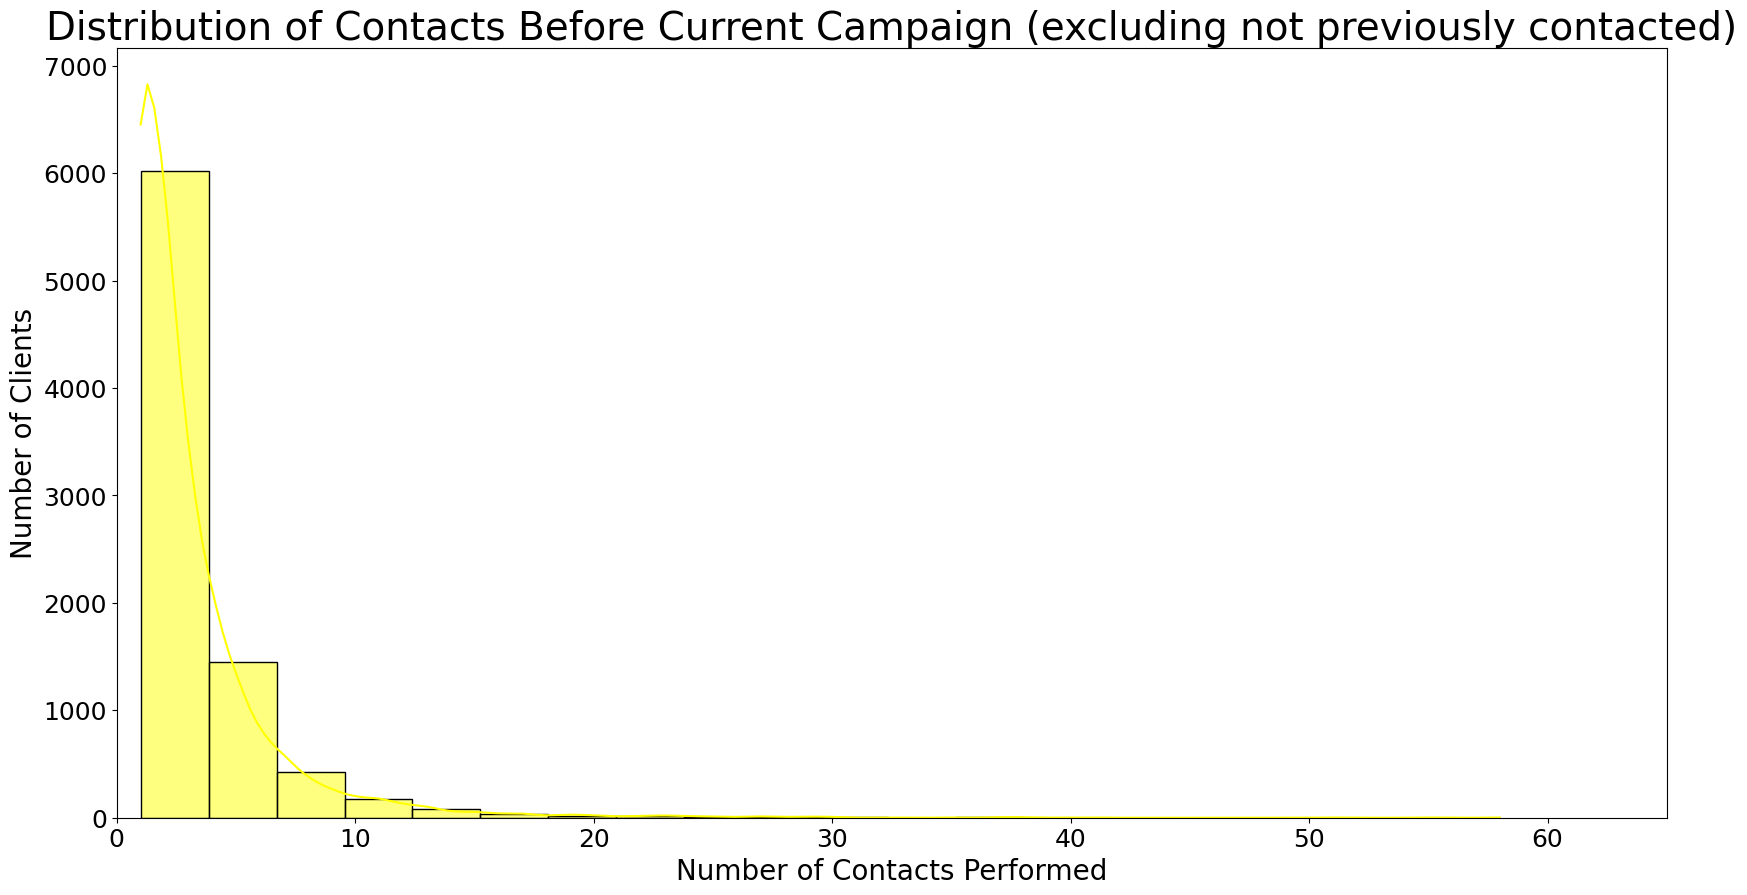

count    8255.000000
mean        3.145972
std         3.443354
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        58.000000
dtype: float64
Clients previously contacted: 8255
Clients not previously contacted: 36955


In [42]:
print(df['previous'].value_counts())
print(df['previous'].describe())

# Exclude 0 and outlier 275
previously_contacted_clients = df[(df['previous'] != 0) & (df['previous'] != 275)]['previous'].tolist()

plt.figure(figsize=(20, 10))
sns.histplot(x=previously_contacted_clients, kde=True, bins=20, color='yellow')
plt.xlabel('Number of Contacts Performed', fontsize=20)
plt.ylabel('Number of Clients', fontsize=20)
plt.title('Distribution of Contacts Before Current Campaign (excluding not previously contacted)', fontsize=28)
plt.yticks(fontsize=18)
plt.xlim(0, 65)
plt.xticks(fontsize=18)
plt.show()

p = pd.Series(previously_contacted_clients)
print(p.describe())
print(f'Clients previously contacted: {len(previously_contacted_clients)}')
print(f'Clients not previously contacted: {df["previous"].count() - len(previously_contacted_clients)}')

poutcome
unknown    36959
failure     4900
other       1838
success     1513
Name: count, dtype: int64


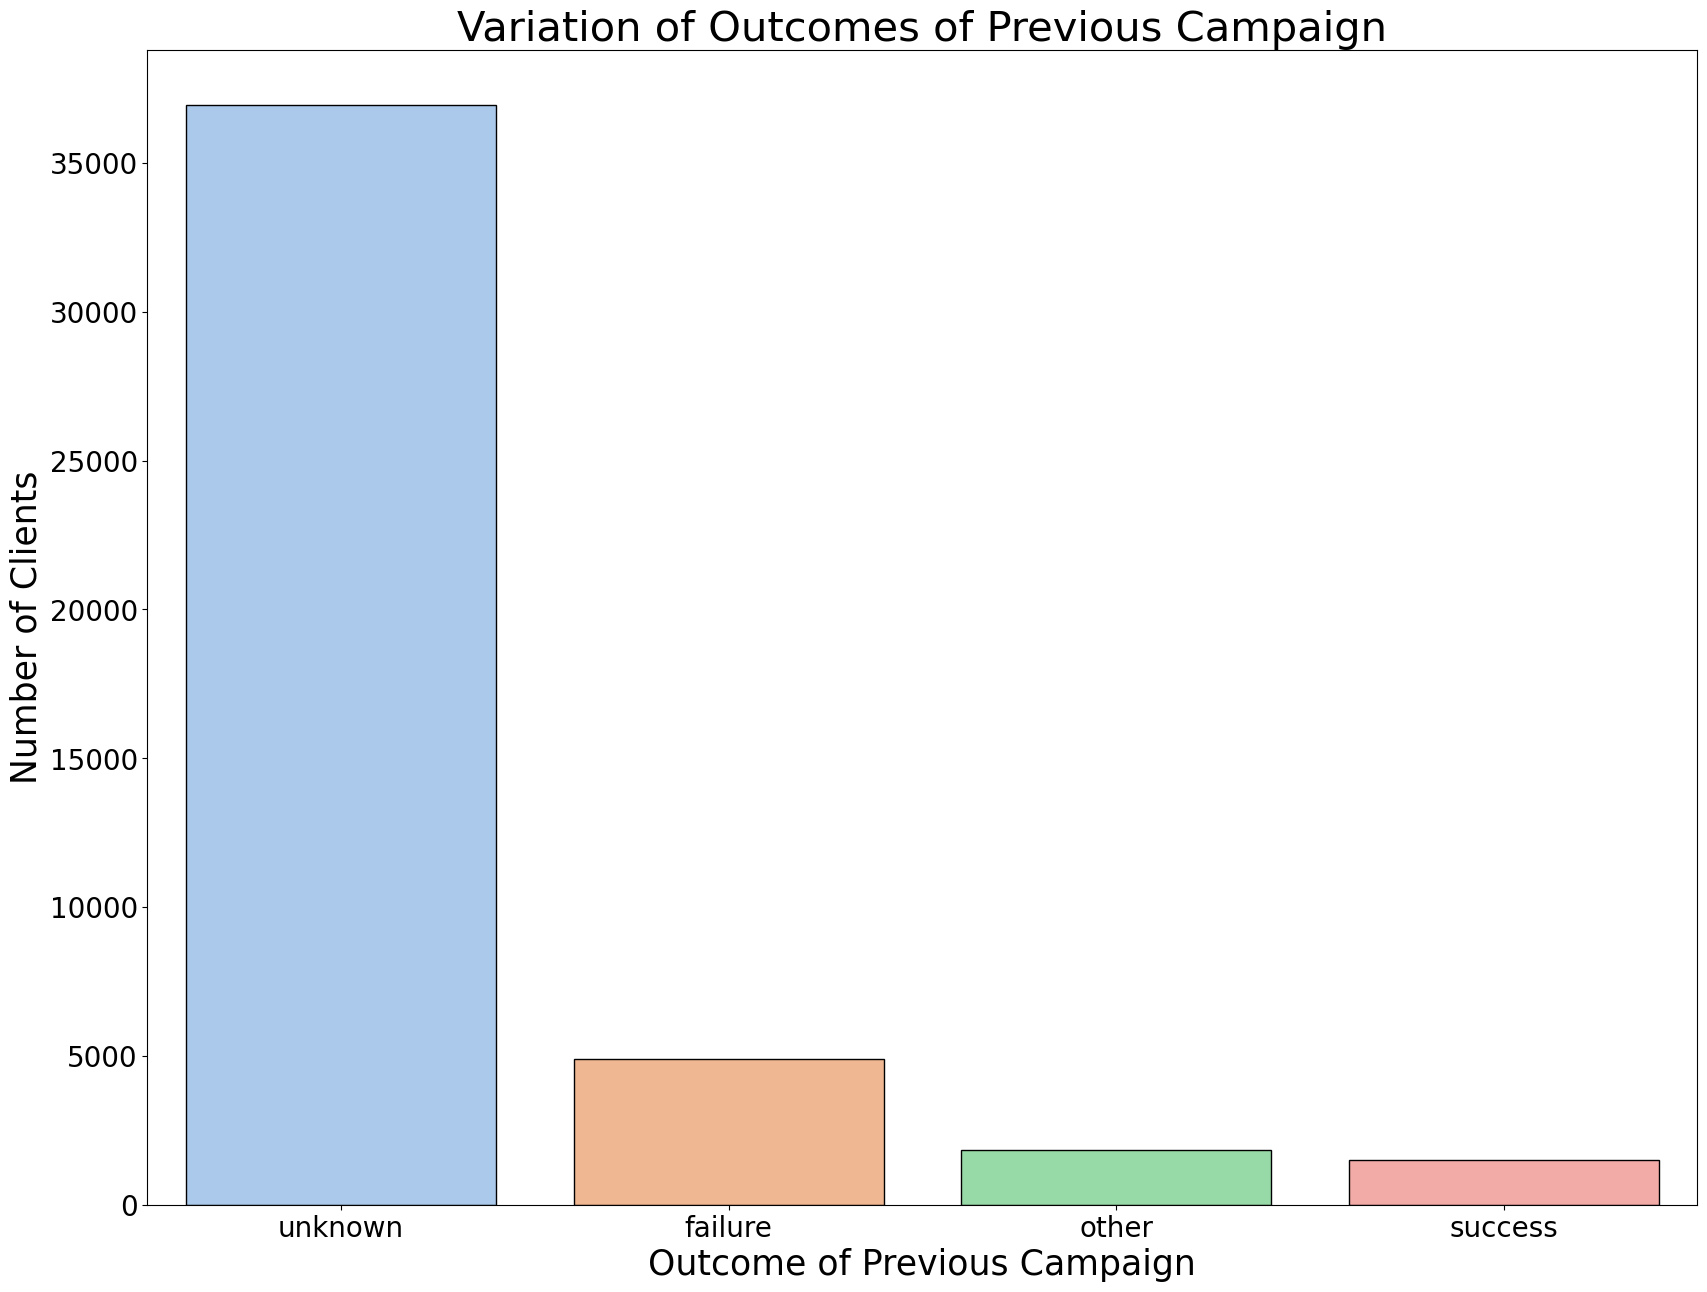

In [44]:
print(df['poutcome'].value_counts())

plt.figure(figsize=(20, 15))
sns.countplot(data=df, x='poutcome', palette='pastel', edgecolor='black')
plt.xlabel('Outcome of Previous Campaign', fontsize=25)
plt.ylabel('Number of Clients', fontsize=25)
plt.title('Variation of Outcomes of Previous Campaign', fontsize=30)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

y
no     39917
yes     5293
Name: count, dtype: int64


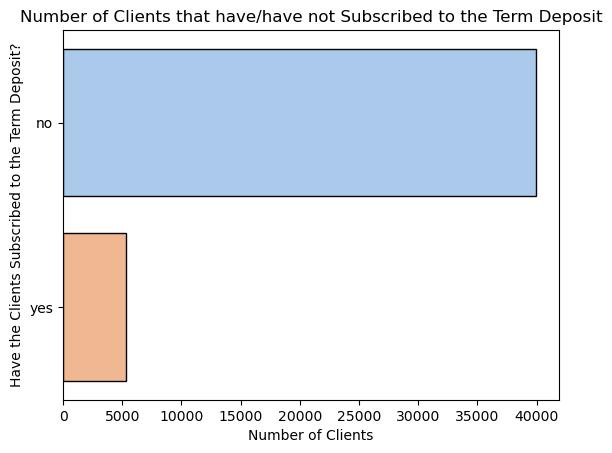

In [46]:
print(df['y'].value_counts())

sns.countplot(data=df, y='y', palette='pastel', edgecolor='black')
plt.ylabel('Have the Clients Subscribed to the Term Deposit?')
plt.xlabel('Number of Clients')
plt.title('Number of Clients that have/have not Subscribed to the Term Deposit')
plt.show()

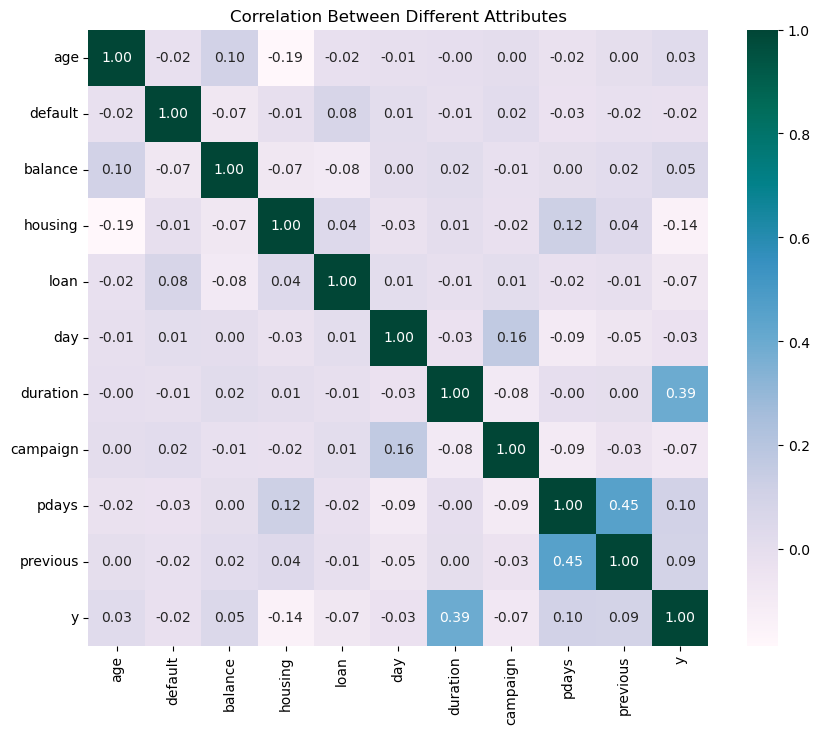

In [48]:
df['housing'].replace({'yes': 1, 'no': 0}, inplace=True)
df['loan'].replace({'yes': 1, 'no': 0}, inplace=True)
df['default'].replace({'yes': 1, 'no': 0}, inplace=True)
df['y'].replace({'yes': 1, 'no': 0}, inplace=True)

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='PuBuGn', fmt='.2f')
plt.title('Correlation Between Different Attributes')
plt.show()

df['y'].replace({1: 'yes', 0: 'no'}, inplace=True)

marital   y  
divorced  no      4584
          yes      623
married   no     24458
          yes     2758
single    no     10875
          yes     1912
Name: y, dtype: int64


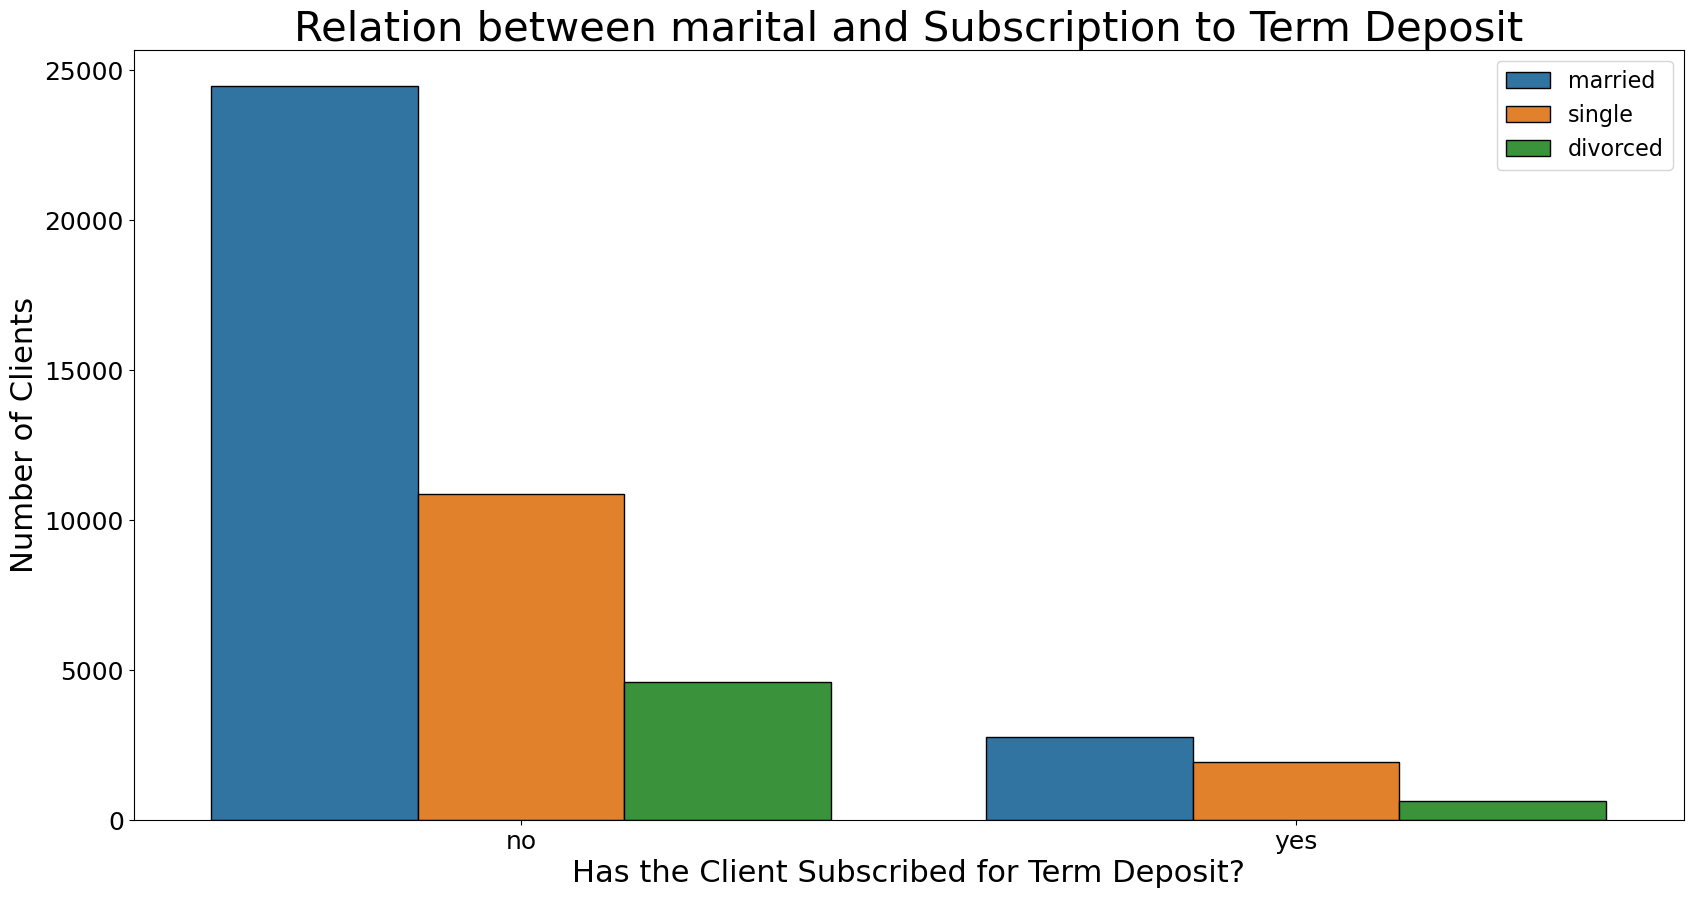

poutcome  y  
failure   no      4281
          yes      619
other     no      1531
          yes      307
success   no       533
          yes      980
unknown   no     33572
          yes     3387
Name: y, dtype: int64


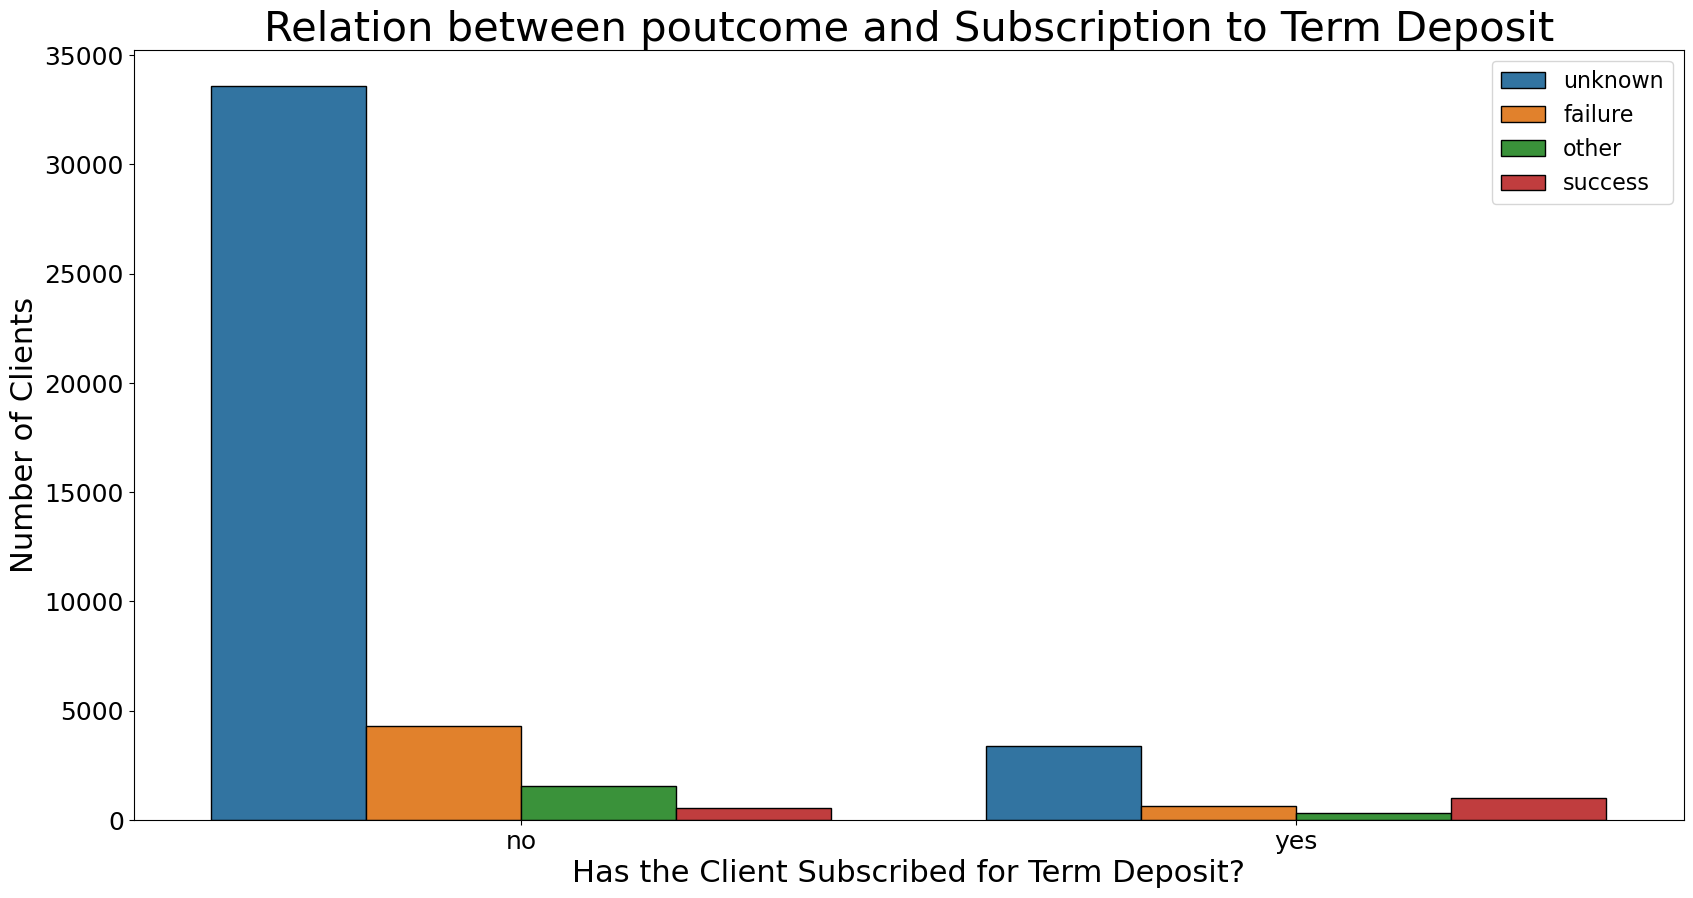

education  y  
primary    no      6259
           yes      592
secondary  no     20749
           yes     2452
tertiary   no     11304
           yes     1997
unknown    no      1605
           yes      252
Name: y, dtype: int64


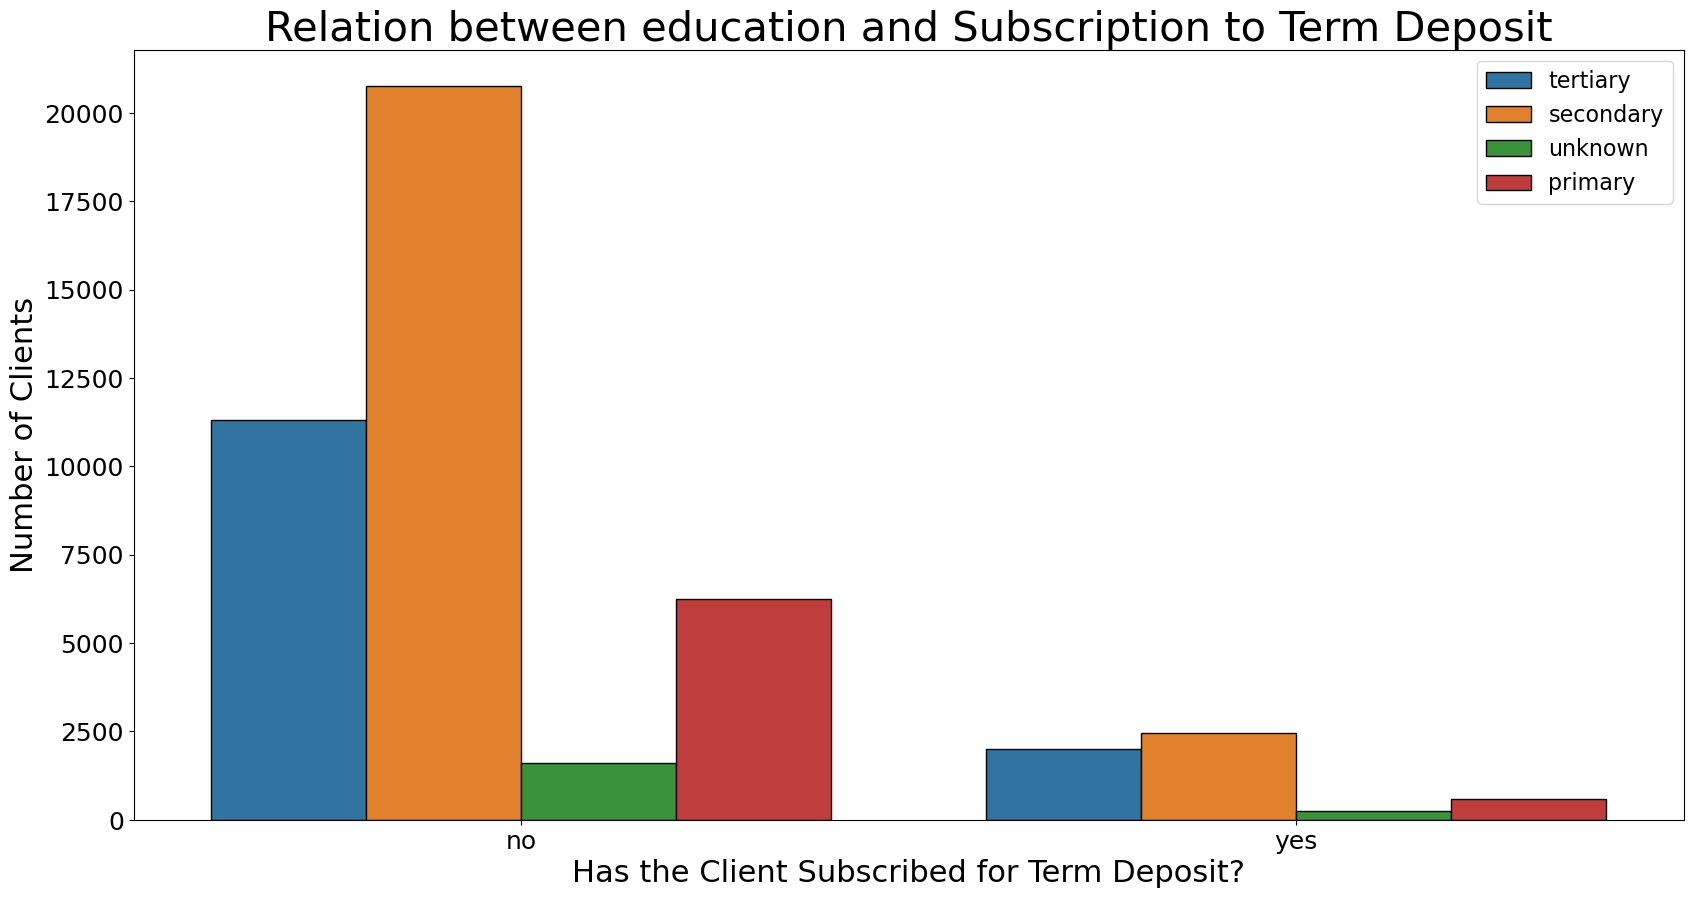

job            y  
admin.         no     4540
               yes     631
blue-collar    no     9023
               yes     708
entrepreneur   no     1364
               yes     123
housemaid      no     1131
               yes     109
management     no     8156
               yes    1302
retired        no     1747
               yes     519
self-employed  no     1392
               yes     187
services       no     3785
               yes     369
student        no      667
               yes     269
technician     no     6757
               yes     840
unemployed     no     1101
               yes     202
unknown        no      254
               yes      34
Name: y, dtype: int64


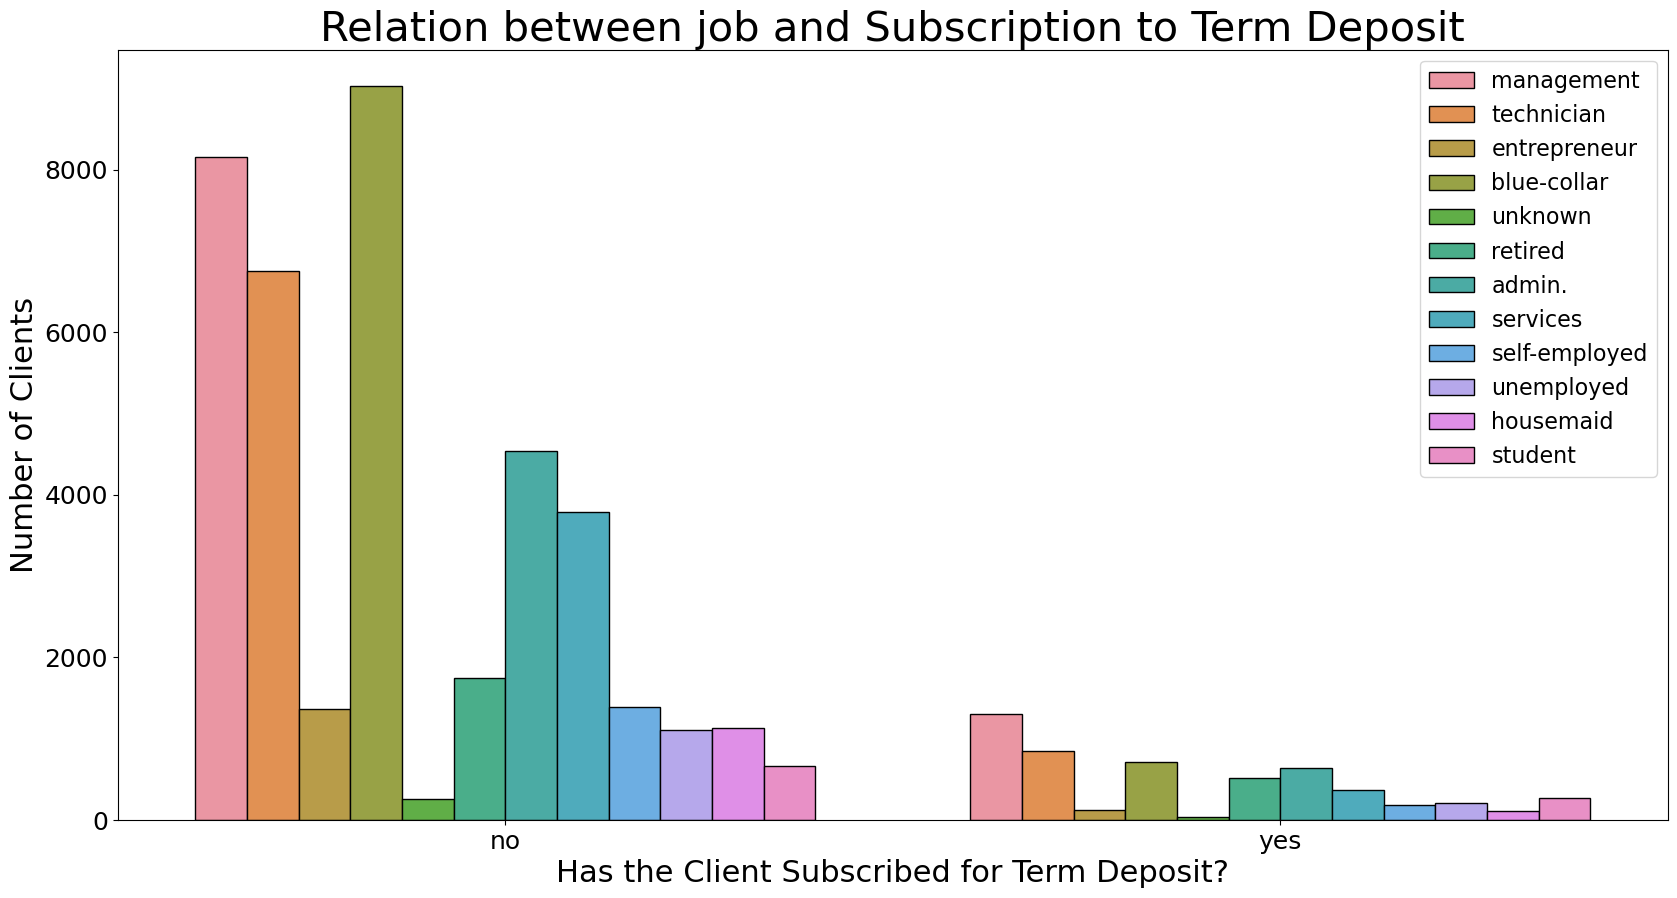

contact    y  
cellular   no     24915
           yes     4373
telephone  no      2512
           yes      390
unknown    no     12490
           yes      530
Name: y, dtype: int64


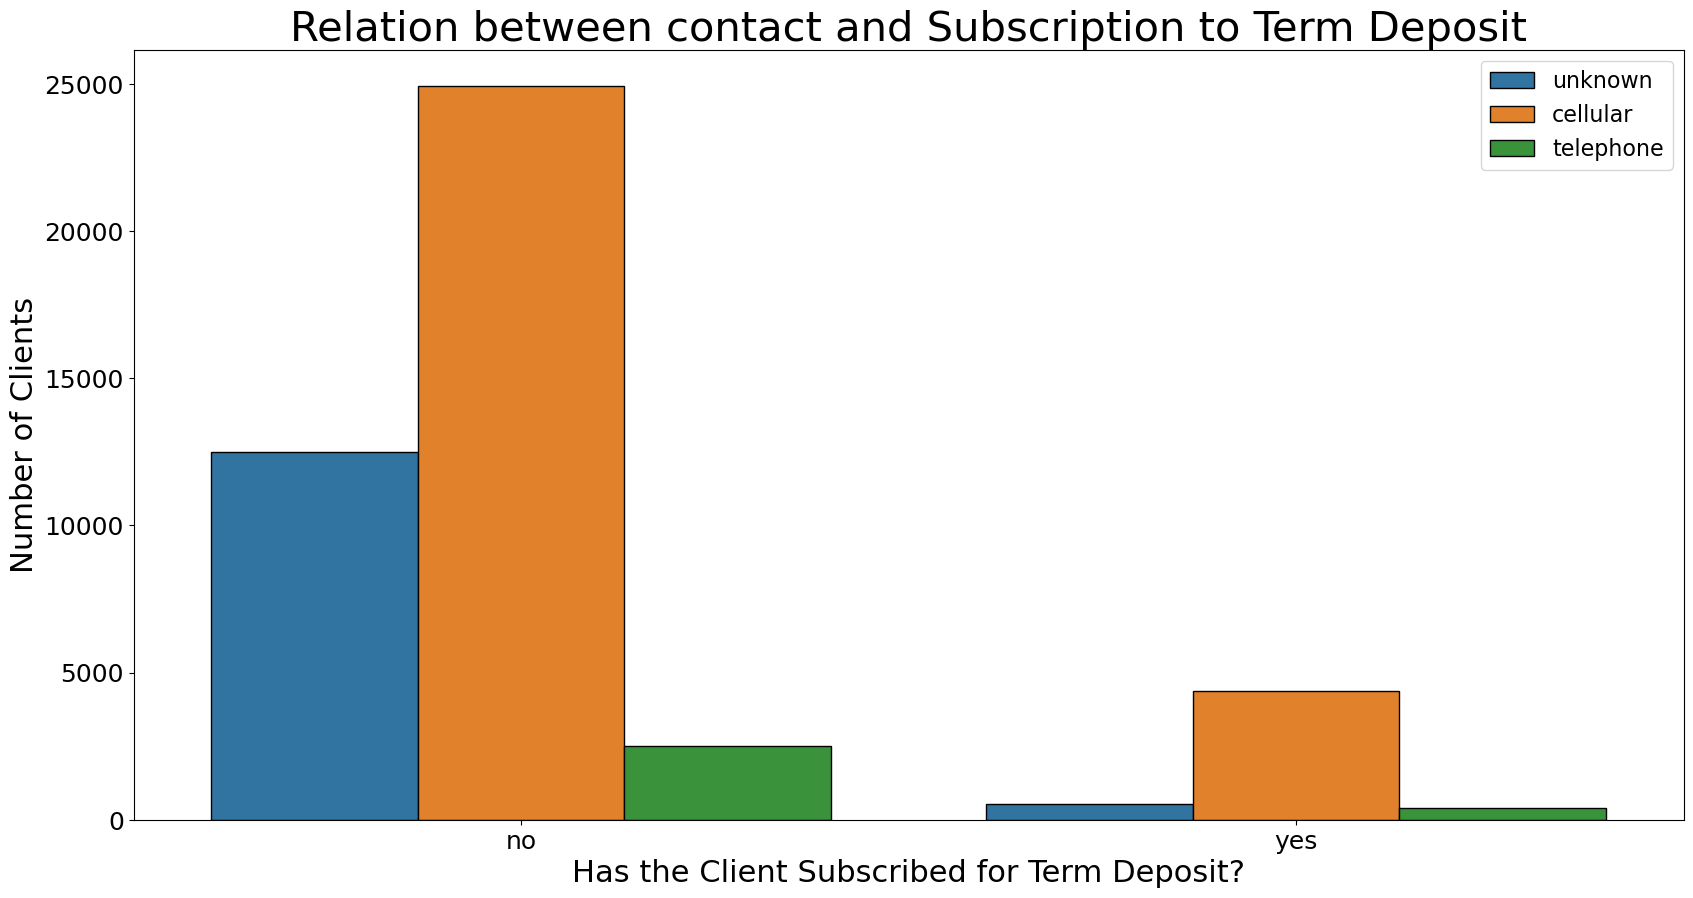

In [50]:
non_numeric_columns = [df['marital'], df['poutcome'], df['education'], df['job'], df['contact']]

for column in non_numeric_columns:
    print(df.groupby([column, 'y'])['y'].count())
    
    plt.figure(figsize=(20, 10))
    sns.countplot(x='y', hue=column.name, data=df, edgecolor='black')
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlabel('Has the Client Subscribed for Term Deposit?', fontsize=22)
    plt.ylabel('Number of Clients', fontsize=22)
    plt.title(f'Relation between {column.name} and Subscription to Term Deposit', fontsize=30)
    plt.legend(fontsize=16)
    plt.show()